# Clustering PsAID-12 | Describe Clusters
April 2025 Patty de Groot

## Comments to change

TO DO: 
- Describe clusters with heatmaps per variable score (PsAID Heatmap = CHECK, Clinical_Vars = TO DO)
- Change axes ranges to better indicate differences between clusters
  - Boxplot = [DONE]
  - Radial Graph = TO DO
- Kruskal Wallis test by clinical vars not possible becauseof NA / NAN? [DONE]

## Initialization

In [59]:
## Set up
## Import Packages
import warnings
import os
import math

import pandas as pd
import numpy as np
import re # Regular Expressions
import textwrap

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import plotly.express as px

import seaborn as sns

import sklearn
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score, fowlkes_mallows_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE

import scipy
from scipy.stats import norm, skew, kurtosis, iqr
from scipy import stats
from scipy.stats import chi2_contingency

import scikit_posthocs as sp

import plotly
import plotly.graph_objects as go

# Suppress Future Warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Select Random Seed
RandomSeed = 42

### CHOOSE SETTINGS FOR RUNNING CODE

In [2]:
"""
Skip certain sections of the code for time purposes
debugmode = True  --> SKIP 'by PsAID Domains.'
debugmode = False --> compute all cells
"""

debugmode = False
skip_pairplot = False
storefigures = True
by_algorithm = False
selected_solutions = True

### Choose which dataset to describe

In [3]:
if by_algorithm:
    print(by_algorithm)
    ## Choose Algorithm
    #algorithm = 'KMeans++'
    # algorithm = 'Hierarchical Clustering'
    # algorithm = 'Spectral Clustering'
    algorithm = 'Mixture Models'
    
    ## Specify Storage Paths
    figure_storage = f"/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_{algorithm}/Figures/Describe Clusters"
    data_storage = f"/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_{algorithm}"
    
    # Import Dataset
    if algorithm == 'Spectral Clustering':
        data_complete = pd.read_csv(f'{data_storage}/PsAID_{algorithm}_Clusters_Div10.csv') # Import dataset
    else:
        data_complete = pd.read_csv(f'{data_storage}/PsAID_{algorithm}_Clusters.csv') # Import dataset
    
if selected_solutions:
    print('selected solutions')
    data_complete = pd.read_csv('/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_Pre-Processing & Inspection/PsAID_Preprocessed.csv')

    # Add clustering solutions
    for algorithm in ['KMeans++', 'Hierarchical Clustering', 'Spectral Clustering', 'Mixture Models']:  #'Hierarchical Clustering', 'Spectral Clustering',
        print(algorithm)
        if algorithm == 'Spectral Clustering':
            cluster_data = pd.read_csv(f'/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_{algorithm}/PsAID_{algorithm}_Clusters_Div10.csv', usecols=lambda col: col in ['respondentid', 'mm'] or col.startswith('clusterID_')) # Import dataset
        else:
            cluster_data = pd.read_csv(f'/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/PsAID_{algorithm}/PsAID_{algorithm}_Clusters.csv', usecols=lambda col: col in ['respondentid', 'mm'] or col.startswith('clusterID_'))

        # Merge cluster_data with data_complete
        print(f'Shape_prior: {data_complete.shape}')
        data_complete = pd.merge(data_complete, cluster_data, on = ['respondentid', 'mm'], how = 'left')
        print(f'Shape_after: {data_complete.shape}')
        data_complete.columns

data_complete.head() # Check data
data_complete.info()

cluster_data.info()

selected solutions
KMeans++
Shape_prior: (5099, 37)
Shape_after: (5099, 45)
Hierarchical Clustering
Shape_prior: (5099, 45)
Shape_after: (5099, 59)
Spectral Clustering
Shape_prior: (5099, 59)
Shape_after: (5099, 71)
Mixture Models
Shape_prior: (5099, 71)
Shape_after: (5099, 86)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 86 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   respondentid                         5099 non-null   int64  
 1   mm                                   5099 non-null   int64  
 2   submitdate                           5099 non-null   object 
 3   gp01                                 5099 non-null   int64  
 4   gp02                                 5099 non-null   int64  
 5   gp03                                 5099 non-null   int64  
 6   gp04                                 5099 non-null   int64  
 7   gp05           

In [4]:
## Define Varlists
columns_gp = [i for i in data_complete.columns if re.match(r'^gp\d{2}$',i)]
cluster_columns = [i for i in data_complete.columns if re.match(r'^clusterID_',i)]
demographic_variables = ['Geslacht', 'age', 'bmi', 'packyear', 'pm86b']
clinical_variables = ['popsjc', 'poptjc', 'lei_mases', 'bsa', 'fv101a', 'fv103a', 'fv102a'] #['crp', 'dactcount']
disease_states = ['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state' ] 
composite_scores = ['dapsa', 'pasdas', 'psaid12'] 

In [5]:
## Format Dataset
# floats to ints
data_complete[['age', 'popsjc', 'poptjc', 'lei_mases', 'dactcount', 'fv101a', 'fv103a', 'fv102a']] = data_complete[['age', 'popsjc', 'poptjc', 'lei_mases', 'dactcount', 'fv101a', 'fv103a', 'fv102a']].astype('Int64')
# floats to categories
data_complete[['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state']] = data_complete[['dapsa_state', 'pasdas_state', 'mda_state', 'psaid_state']].astype('Int64').astype('category')
# objects to categories
data_complete['Geslacht'] = data_complete['Geslacht'].astype('category')
# objects to datetime
data_complete['submitdate'] = pd.to_datetime(data_complete['submitdate'])

## Subset Dataset
psaid12 = data_complete[['respondentid', 'mm'] + columns_gp + ['psaid12'] + cluster_columns]

## Dictionary
domains_dict = {
    'gp01': 'Pain',
    'gp02': 'Fatigue',
    'gp03': 'Skin problems',
    'gp04': 'Work-Leisure activities',
    'gp05': 'Functional Capacity',
    'gp06': 'Discomfort',
    'gp07': 'Sleep disturbance',
    'gp08': 'Coping',
    'gp09': 'Anxiety/Fear/Uncertainty',
    'gp10': 'Shame',
    'gp11': 'Social Participation',
    'gp12': 'Depression'
}

clinical_vars_dict = {
    'popsjc' : 'Swollen joints', 
    'poptjc' : 'Tender joints', 
    'lei_mases': 'Enthesitis', 
    'dactcount': 'Dactylitis', 
    'bsa' : 'Psoriasis', 
    'crp' : 'CRP', 
    'fv101a': 'VAS RN Global', 
    'fv103a': 'VAS RN Arthritis', 
    'fv102a': 'VAS RN Psoriasis',
}

states_dict = {
    'dapsa_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'}, 
    'pasdas_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'}, 
    'mda_state': {0: 'VLDA', 1: 'MDA', 2: 'No MDA'}, 
    'psaid_state': {0: 'Remission', 1: 'Low', 2: 'Moderate', 3: 'High'}
}

# Max values for Heatmap Clinical Variables
# For Heatmap Colors
clinical_vars_ylimHM= {
    'popsjc': 12, 
     'poptjc': 20,
     'lei_mases': 5,
     'dactcount': 5,
     'bsa': 10,       # BSA <3 = mild, 3-10 = Moderate, > 10 Severe
     'crp': 100,      # CRP levels are generally considered to be normal < 3 mg/L, Mildly elevated 3-10 mg/L, Moderate 10-100 mg/L, High 100-500 mb/L, Very High >500 mg/L. HOWEVER, old CRP test could not reliably measure CRP below 5 mg/L
     'fv101a': 50,    # PhGA low <10, Moderate 10-30, High 30-50, Very high >50 (MDA cutoff = <20)
     'fv103a': 50,
     'fv102a': 50
}
#For Radial Chart Axes
clinical_vars_ylimRC= {
    'popsjc': 5, 
     'poptjc': 5,
     'lei_mases': 5,
     'dactcount': 5,
     'bsa': 10,
     'crp': 10,      # CRP levels are generally considered to be normal < 3 mg/L, Mildly elevated 3-10 mg/L, Moderate 10-100 mg/L, High 100-500 mb/L, Very High >500 mg/L. HOWEVER, old CRP test could not reliably measure CRP below 5 mg/L
     'fv101a': 30,   # PhGA low <10, Moderate 10-30, High 30-60, Very high >60 
     'fv103a': 30,
     'fv102a': 30
}

# https://pmc.ncbi.nlm.nih.gov/articles/PMC8528225/#S2 
# POP SJC + TJC : Patients enrolled in trials have a mean TJC of 20 and SJC 12. The counts are often much lower in clinical practice and longitudinal observational cohort studies. Patients with low joint counts (oligoarthritis <5 joints (=TJC + SJC)). Patients with high joint counts (Poliarthritis >5 (TJC + SJC).
# LEIMASES:  


# ## Codebook 
# print(f' The imported PsAID dataset contains {len(psaid12)} datapoints')
# psaid_codebook = pd.DataFrame({
#     'Variable' : psaid12.columns.tolist(),
#     'Data_type' : psaid12.dtypes.tolist(),
#     'Description' : ['Participant', 'Moment of measurement', 'Date of completion', 'Q1 pain', 'Q2 fatigue', 'Q3 skin', 'Q4 work-recreational activities', 'Q5 bodily functioning', 'Q6 discomfort', 'Q7 sleep', 'Q8 coping', 'Q9 anxiety','Q10 shame', 'Q11 social activities', 'Q12 depression', 'PsAID12 Total score', 'Cluster Assignment', 'Cluster Assignment', 'Cluster Assignment', 'Cluster Assignment'],
#     'Exact Question': [ '-',
#                         '-',
#                         '-',
#                         'Kies het getal dat het beste de pijn beschrijft die u voelde als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de mate van vermoeidheid beschrijft die u voelde als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de huidproblemen (inclusief jeuk) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de moeilijkheden beschrijft die u ondervond om volwaardig deel te nemen aan werk- en/of vrije tijdsactiviteiten als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de moeilijkheden met dagelijkse lichamelijke activiteiten beschrijft die u ondervond als gevolg van van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste het gevoel van ongemak en ergernis bij alledaagse activiteiten beschrijft als gevolg van uw artritis psoriatica in de afgelopen week.',
#                         'Kies het getal dat het beste de slaapproblemen (bijv. uw nachtrust) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kijkend naar uw artritis psoriatica in het algemeen, hoe goed kon u met uw ziekte omgaan gedurende de afgelopen week?',
#                         'Kies het getal dat het beste de mate van angst, bezorgdheid en onzekerheid (bijv. over de toekomst, behandelingen, angst voor eenzaamheid) beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Uw artritis psoriatica in het algemeen genomen, kies het getal dat het beste de mate van schaamte beschrijft die u ondervond als gevolg van de zichtbaarheid van uw ziekte gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de problemen beschrijft die u had om volledig aan sociale activiteiten deel te nemen (inclusief relaties met familie en vrienden) als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         'Kies het getal dat het beste de mate van depressie en/of neerslachtigheid beschrijft die u ondervond als gevolg van uw artritis psoriatica gedurende de afgelopen week.',
#                         '-', 
#                         'Cluster resultaten K = 3',
#                         'Cluster resultaten K = 4',
#                         'Cluster resultaten K = 5',
#                         'Cluster resultaten K = 6'
#                         ]
# })
# psaid_codebook 

In [6]:
psaid12.head()

,respondentid,mm,gp01,gp02,gp03,gp04,gp05,gp06,gp07,gp08,...,clusterID_gsemPoisson_k3,clusterID_gsemPoisson_k4,clusterID_gsemPoisson_k5,clusterID_gsemPoisson_k6,clusterID_gsemPoisson_k7,clusterID_gsemWeibull_k3,clusterID_gsemWeibull_k4,clusterID_gsemWeibull_k5,clusterID_gsemWeibull_k6,clusterID_gsemWeibull_k7
0,78195329,36,2,2,2,2,2,0,1,0,...,2,1,5,1,4,1,4,2,6,7
1,10862915,6,1,6,2,1,1,1,1,1,...,3,1,5,1,2,1,4,5,5,5
2,29370588,18,6,7,5,6,4,6,7,5,...,1,2,2,4,1,3,2,4,2,6
3,87648336,18,0,4,5,0,0,0,0,0,...,2,4,5,1,4,2,4,2,6,7
4,42677901,84,0,0,0,0,0,0,0,0,...,2,4,4,6,3,2,1,1,1,2


In [7]:
data_complete.info()
data_complete.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 86 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   respondentid                         5099 non-null   int64         
 1   mm                                   5099 non-null   int64         
 2   submitdate                           5099 non-null   datetime64[ns]
 3   gp01                                 5099 non-null   int64         
 4   gp02                                 5099 non-null   int64         
 5   gp03                                 5099 non-null   int64         
 6   gp04                                 5099 non-null   int64         
 7   gp05                                 5099 non-null   int64         
 8   gp06                                 5099 non-null   int64         
 9   gp07                                 5099 non-null   int64         
 10  gp08        

(5099, 86)

### Remap cluster labels based on Total PsAID Score

In [8]:
# Establish parity between the assigned clusters   
def remap_clusterlabels(data, cluster_columns, byvar, column_gp, verbose=True):
    """
    Remap cluster labels based on the total score (ascending).
    Parameters:
    - data: pandas DataFrame containing the data
    - describe_clusters: column name of the cluster labels
    - byvar: column name of the score used for ordering
    
    Returns:
    - dataframe with remapped cluster labels. stores old labels in _OG column
    """
    df = data.copy()

    for col in cluster_columns:
        print(f'\nRemapping {col}:')
        # Calculate total PsAID12 score per cluster
        cluster_scores = df.groupby(col)[byvar].median()
    
        # Relabel based on sorted total scores 
        sorted_clusters = cluster_scores.sort_values().index #Sort clusters by total score
        cluster_mapping = {old_label: new_index for new_index, old_label in enumerate(sorted_clusters)} # Create mapping from old cluster label to new label
        print(f'Cluster mapping (old -> new): {cluster_mapping}')
        remapped_clusters = df[col].map(cluster_mapping)+1 # Apply mapping and make clusters start from 1.
        print(remapped_clusters)
    
        # Check mapping and total PsAID Scores
        summary = pd.DataFrame({
                'Original Label': cluster_scores .index,
                'Total Score': cluster_scores .values,
                'New Label': [cluster_mapping[old_label] for old_label in cluster_scores .index]
            }).set_index('New Label').sort_index()
    
        print("\nCluster total scores (sorted by new label):")
        print(summary)
    
        # Check cluster sizes
        cluster_size_check = pd.DataFrame({
            'Original Cluster Counts': df[col].value_counts().sort_index(),
            'Remapped Cluster Counts': remapped_clusters.value_counts().sort_index()
            })
        print("\nCluster sizes (should match):")
        print(cluster_size_check)
    
        # Store mapped labels
        df[col+'_OG'] = df[col]
        df[col] = remapped_clusters

    # Subset Dataset
    df_psaid = df[['respondentid', 'mm'] + columns_gp + [byvar] + cluster_columns]

    return df, df_psaid

In [9]:
data_complete, psaid12 = remap_clusterlabels(data_complete, cluster_columns, 'psaid12', columns_gp)


Remapping clusterID_k3:
Cluster mapping (old -> new): {1: 0, 2: 1, 0: 2}
0       1
1       1
2       3
3       1
4       1
       ..
5094    2
5095    2
5096    3
5097    3
5098    1
Name: clusterID_k3, Length: 5099, dtype: int64

Cluster total scores (sorted by new label):
           Original Label  Total Score
New Label                             
0                       1         0.75
1                       2         3.45
2                       0         6.10

Cluster sizes (should match):
              Original Cluster Counts  Remapped Cluster Counts
clusterID_k3                                                  
0                               979.0                      NaN
1                              2575.0                   2575.0
2                              1545.0                   1545.0
3                                 NaN                    979.0

Remapping clusterID_k4:
Cluster mapping (old -> new): {1: 0, 2: 1, 3: 2, 0: 3}
0       1
1       2
2       4
3       1


/var/folders/v1/cgk6jb695096vx3ms_0jd97m0000gn/T/ipykernel_38331/4072462157.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col+'_OG'] = df[col]


### Choose which cluster to describe

In [10]:
print(cluster_columns)

['clusterID_k3', 'clusterID_k4', 'clusterID_k5', 'clusterID_k6', 'clusterID_k7', 'clusterID_k8', 'clusterID_k9', 'clusterID_k10', 'clusterID_ward_k2', 'clusterID_ward_k3', 'clusterID_ward_k5', 'clusterID_ward_k7', 'clusterID_average_k2', 'clusterID_average_k3', 'clusterID_average_k5', 'clusterID_averageL1_k3', 'clusterID_averageL1_k6', 'clusterID_complete_k2', 'clusterID_complete_k3', 'clusterID_complete_k4', 'clusterID_completeL1_k2', 'clusterID_completeL1_k3', 'clusterID_div10_rbf3.9_kmeansk3', 'clusterID_div10_rbf3.9_cluster_qrk3', 'clusterID_div10_rbf5.7_kmeansk4', 'clusterID_div10_rbf5.1_kmeansk5', 'clusterID_div10_rbf4.5_cluster_qrk5', 'clusterID_div10_rbf3.9_kmeansk6', 'clusterID_div10_rbf5.1_cluster_qrk6', 'clusterID_div10_rbf3.9_kmeansk7', 'clusterID_div10_rbf3.9_cluster_qrk7', 'clusterID_div10_rbf3.9_cluster_qrk8', 'clusterID_div10_rbf3.9_kmeansk9', 'clusterID_div10_rbf3.9_cluster_qrk9', 'clusterID_gsemGauss_k3', 'clusterID_gsemGauss_k4', 'clusterID_gsemGauss_k5', 'clusterID_

In [11]:
## Describe clusters of settings:
if by_algorithm:
    if algorithm == 'KMeans++':
        describe_clusters = 'clusterID_k5' #[k=3, 4, 5, 6]
    elif algorithm == 'Hierarchical Clustering':
        describe_clusters = 'clusterID_ward_k7' #k=[3, 5, 7]
    elif algorithm == 'Spectral Clustering':
        describe_clusters = cluster_columns[0]
    elif algorithm == 'Mixture Models': 
        describe_clusters = cluster_columns[0]
     
    print(f' \n selected clusters: {describe_clusters}')

    ## Update Figure storage
    figure_storage = os.path.join(figure_storage, describe_clusters) # Update Figure Storage
    os.makedirs(figure_storage, exist_ok=True) # Create the folder if it doesn't exist

if selected_solutions:
    #describe_clusters = 'clusterID_k3'            #K = 3 (Kmeans++)
    #describe_clusters = 'clusterID_gsemGauss_k4'  #K = 4 (GSEM Gauss)
    #describe_clusters = 'clusterID_gsemGauss_k5'  #K = 5 (GSEM Gauss)
    describe_clusters = 'clusterID_gsemGauss_k6'   #K = 6 (GSEM Gauss)
    #describe_clusters = 'clusterID_gsemGauss_k7'  #K = 7 (GSEM Gauss)

    storage_location = "/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Selected Clustering Solutions"
    data_storage = f"{storage_location}/PsAID_{describe_clusters}"
    figure_storage = f"{storage_location}/PsAID_{describe_clusters}/Figures"
    
    # Create directories if they don't exist
    os.makedirs(data_storage, exist_ok=True)
    os.makedirs(figure_storage, exist_ok=True)

## Data dictated limits:
clinical_vars_ylimBP = {
    'popsjc': data_complete[[describe_clusters, 'popsjc']].groupby(describe_clusters).quantile(0.95).max().max()+0.5,
    'poptjc': data_complete[[describe_clusters, 'poptjc']].groupby(describe_clusters).quantile(0.95).max().max()+0.5,
    'lei_mases': data_complete[[describe_clusters, 'lei_mases']].groupby(describe_clusters).quantile(0.95).max().max()+0.5,
    'dactcount': data_complete[[describe_clusters, 'dactcount']].groupby(describe_clusters).quantile(0.95).max().max()+0.5,
    'bsa': data_complete[[describe_clusters, 'bsa']].groupby(describe_clusters).quantile(0.95).max().max()+0.5,
    'crp': data_complete[[describe_clusters, 'crp']].groupby(describe_clusters).quantile(0.95).max().max()+0.5,
    'fv101a': data_complete[[describe_clusters, 'fv101a']].groupby(describe_clusters).quantile(0.95).max().max()+0.5,
    'fv103a': data_complete[[describe_clusters, 'fv103a']].groupby(describe_clusters).quantile(0.95).max().max()+0.5,
    'fv102a': data_complete[[describe_clusters, 'fv102a']].groupby(describe_clusters).quantile(0.95).max().max()+0.5
}

## Descriptive statistics by cluster

### Stats Table

In [12]:
describe_clusters

'clusterID_gsemGauss_k6'

#### Cluster Size & Variance

In [13]:
# Cluster Size & Variance
def cluster_size_spread(data, cluster_assignment, byvar):
    """

    """
    cluster_centers_mean = pd.DataFrame()
    cluster_size = pd.DataFrame()
    cluster_spread = pd.DataFrame()

    cluster_size = pd.Series(data[cluster_assignment]).value_counts().sort_index().values # Compute cluster sizes

    # Determine cluster Variance
    cluster_spread = pd.Series(data.groupby(cluster_assignment)[byvar]
            .var()  # Compute variance for each cluster
            .mean(axis=1)).values  # Average variance across all dimensions

    print(f'Cluster Sizes: \n {cluster_size} \n')
    print(f'Cluster Variances: \n {cluster_spread} \n')

    return cluster_size, cluster_spread

In [14]:
cluster_size, cluster_spread = cluster_size_spread(psaid12, describe_clusters, columns_gp)

Cluster Sizes: 
 [2143 1110  580  392  517  357] 

Cluster Variances: 
 [0.92519398 2.55778317 3.31501945 3.6968831  3.6516526  2.92618602] 



#### Mean std, median iqr

In [15]:
# Mean and std
# Create a function to calculate mean and std for each variable in the clusters
def calc_cluster_stats(data, clusterID, varlist):
    """
    Calculate the mean and std for all PsAID Domains for each cluster
    """
    
    # Group by cluster assignment column
    cluster_stats = data[varlist + [clusterID]].groupby(clusterID).agg(['mean', 'std', 'median', ('IQR', lambda x: iqr(x, nan_policy='omit')), ('Q1', lambda x: np.nanpercentile(x, 25)), ('Q3', lambda x: np.nanpercentile(x, 75))])
    #cluster_stats = data[varlist + [clusterID]].groupby(clusterID).agg([

    # Calculate the mean and std for the complete dataset
    complete_stats = data[varlist].agg(['mean', 'std']).T
   
    # Reshape the complete dataset statistics to match the cluster_stats structure
    complete_stats_row = complete_stats.stack().reindex(cluster_stats.columns, fill_value=0).to_frame().T  # Flatten mean and std into one row
    complete_stats_row.index = ['Complete Dataset'] # Add an index label for the new row
    
    # Append the complete dataset stats to the cluster stats
    cluster_stats_table = pd.concat([cluster_stats, complete_stats_row], ignore_index=False)

    # Store data
    folder_path = data_storage
    if by_algorithm:
        file_name = f'PsAID_{algorithm}_ClusterStats_Psaid_{clusterID}'
    if selected_solutions:
        file_name = f'PsAID_ClusterStats_Psaid_{clusterID}'
        
    # Ensure the folder exists
    os.makedirs(folder_path, exist_ok=True)
    
    # Save
    cluster_stats_table.to_csv(f'{folder_path}/{file_name}.csv', index=False)
    print(f' Dataset saved to {folder_path}/{file_name}.csv')
    
    return cluster_stats, complete_stats, cluster_stats_table

In [16]:
# Generate the table with mean and std for each cluster and the complete dataset
cluster_stats, complete_stats, cluster_stats_table = calc_cluster_stats(data_complete, describe_clusters, columns_gp)
print(cluster_stats_table) # Display the result

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Selected Clustering Solutions/PsAID_clusterID_gsemGauss_k6/PsAID_ClusterStats_Psaid_clusterID_gsemGauss_k6.csv
                      gp01                                      gp02  \
                      mean       std median  IQR   Q1   Q3      mean   
1                 1.156790  1.305615    1.0  2.0  0.0  2.0  1.089594   
2                 3.672973  1.799782    3.0  3.0  2.0  5.0  3.877477   
3                 5.825862  1.630565    6.0  2.0  5.0  7.0  5.968966   
4                 4.426020  1.874485    5.0  3.0  3.0  6.0  5.591837   
5                 6.882012  1.377985    7.0  2.0  6.0  8.0  7.199226   
6                 7.316527  1.442953    7.0  1.0  7.0  8.0  7.896359   
Complete Dataset  3.498725  2.739678    0.0  0.0  0.0  0.0  3.693665   

                                        ...   gp11                     gp12  \
                       std median  IQR  ... median  IQR   Q1   Q3      mean   
1   

In [17]:
cluster_stats_table

gp01                                      gp02  \
                      mean       std median  IQR   Q1   Q3      mean   
1                 1.156790  1.305615    1.0  2.0  0.0  2.0  1.089594   
2                 3.672973  1.799782    3.0  3.0  2.0  5.0  3.877477   
3                 5.825862  1.630565    6.0  2.0  5.0  7.0  5.968966   
4                 4.426020  1.874485    5.0  3.0  3.0  6.0  5.591837   
5                 6.882012  1.377985    7.0  2.0  6.0  8.0  7.199226   
6                 7.316527  1.442953    7.0  1.0  7.0  8.0  7.896359   
Complete Dataset  3.498725  2.739678    0.0  0.0  0.0  0.0  3.693665   

                                        ...   gp11                     gp12  \
                       std median  IQR  ... median  IQR   Q1   Q3      mean   
1                 1.496463    1.0  2.0  ...    0.0  0.0  0.0  0.0  0.129725   
2                 2.013332    4.0  3.0  ...    1.0  2.0  0.0  2.0  0.711712   
3                 1.830202    6.0  2.0  ...    2.0  4.0  0.0  4.0  0.722414   
4                 1.823892    6.0  3.0  ...    3.0  3.0  2.0  5.0  4.176020   
5                 1.566658    7.0  1.0  ...    5.0  3.0  4.0  7.0  3.338491   
6                 1.335729    8.0  2.0  ...    7.0  2.0  6.0  8.0  7.294118   
Complete Dataset  3.006385    0.0  0.0  ...    0.0  0.0  0.0  0.0  1.461855   

                                                  
                       std median  IQR   Q1   Q3  
1                 0.456275    0.0  0.0  0.0  0.0  
2                 1.140194    0.0  1.0  0.0  1.0  
3                 1.110718    0.0  1.0  0.0  1.0  
4                 1.825407    4.0  2.0  3.0  5.0  
5                 2.322691    3.0  4.0  1.0  5.0  
6                 1.614643    7.0  2.0  6.0  8.0  
Complete Dataset  2.393815    0.0  0.0  0.0  0.0  

[7 rows x 72 columns]

In [18]:
for var in columns_gp+['psaid12']:
    print(var)
    
    # step 2 — compute median, Q1, Q3 and n per cluster
    summary = (
        data_complete
        .groupby(describe_clusters)[var]
        .agg(
            median=lambda x: np.nanmedian(x),
            Q1=lambda x: np.nanpercentile(x, 25),
            Q3=lambda x: np.nanpercentile(x, 75),
            n=lambda x: x.notna().sum()
        )
        .reset_index()
    )
    
    print(summary)


gp01
   clusterID_gsemGauss_k6  median   Q1   Q3     n
0                       1     1.0  0.0  2.0  2143
1                       2     3.0  2.0  5.0  1110
2                       3     6.0  5.0  7.0   580
3                       4     5.0  3.0  6.0   392
4                       5     7.0  6.0  8.0   517
5                       6     7.0  7.0  8.0   357
gp02
   clusterID_gsemGauss_k6  median   Q1   Q3     n
0                       1     1.0  0.0  2.0  2143
1                       2     4.0  2.0  5.0  1110
2                       3     6.0  5.0  7.0   580
3                       4     6.0  4.0  7.0   392
4                       5     7.0  7.0  8.0   517
5                       6     8.0  7.0  9.0   357
gp03
   clusterID_gsemGauss_k6  median   Q1   Q3     n
0                       1     1.0  0.0  2.0  2143
1                       2     2.0  0.0  3.0  1110
2                       3     2.0  0.0  5.0   580
3                       4     4.0  2.0  6.0   392
4                       5     3.0  

#### Kruskal-Wallis Test

In [19]:
#Conduct the Kruskal-Wallis Test 
def kruskal_wallis(data, columns_gp, describe_clusters):
    # Allocate space for the results in a dictionary
    kruskal_results = {}
    
    # Perform Kruskal-Wallis test for each variable
    for var in columns_gp:
        grouped_data = [data[data[describe_clusters] == i][var].dropna() for i in data[describe_clusters].unique()]  # Group data by cluster
        h_statistic, p_value = stats.kruskal(*grouped_data)  # Perform Kruskal-Wallis test
        kruskal_results[var] = {'H-statistic': h_statistic, 'p-value': p_value}
    
    # Print results for each variable
    for var, result in kruskal_results.items():
        print(f"Variable: {var}")
        print(f"H-statistic: {result['H-statistic']:.5f}, p-value: {result['p-value']:.5f}")
        if result['p-value'] < 0.05:
            print('at least one group is significantly different \n')
        elif result['p-value'] >= 0.05:
            print('No significant differences between groups \n')

    return kruskal_results

In [20]:
kruskal_results = kruskal_wallis(psaid12, columns_gp+ ['psaid12'], describe_clusters)
"""The test does not tell you between which groups the difference is, just that at least one group is different"""

Variable: gp01
H-statistic: 3449.12449, p-value: 0.00000
at least one group is significantly different 

Variable: gp02
H-statistic: 3444.04285, p-value: 0.00000
at least one group is significantly different 

Variable: gp03
H-statistic: 1172.84796, p-value: 0.00000
at least one group is significantly different 

Variable: gp04
H-statistic: 4069.28361, p-value: 0.00000
at least one group is significantly different 

Variable: gp05
H-statistic: 4295.22313, p-value: 0.00000
at least one group is significantly different 

Variable: gp06
H-statistic: 4057.58888, p-value: 0.00000
at least one group is significantly different 

Variable: gp07
H-statistic: 2771.79438, p-value: 0.00000
at least one group is significantly different 

Variable: gp08
H-statistic: 3673.80010, p-value: 0.00000
at least one group is significantly different 

Variable: gp09
H-statistic: 3193.33729, p-value: 0.00000
at least one group is significantly different 

Variable: gp10
H-statistic: 2335.65085, p-value: 0.0000

'The test does not tell you between which groups the difference is, just that at least one group is different'

#### Post-hoc Dunns Test

In [21]:
def dunns_test(data, describe_clusters, varlist):
    print('Dunns Test')
    for var in varlist:
        print(f'{var}:')
        posthoc = sp.posthoc_dunn(
            data, 
            val_col=var, 
            group_col=describe_clusters, 
            p_adjust='bonferroni'  #Bonferonni correction for multiple testing
        )
        np.fill_diagonal(posthoc.values, np.nan) 
        #print(posthoc <0.5)
        
        print(f'{posthoc} \n')

        folder_path = f'{data_storage}/DunnsTests'
        if by_algorithm:
            file_name = f'PsAID_{algorithm}_ClusterStats_{describe_clusters}_DunnsTest_{var}'
        if selected_solutions:
            file_name = f'PsAID_ClusterStats_{describe_clusters}_DunnsTest_{var}'
            
        # Ensure the folder exists
        os.makedirs(folder_path, exist_ok=True)
        
        # Save
        posthoc.to_csv(f'{folder_path}/{file_name}.csv', index=False)
        print(f' Dataset saved to {folder_path}/{file_name}.csv')


In [22]:
# Compute Dunns Test
dunns_test(psaid12, describe_clusters, columns_gp+ ['psaid12'])

Dunns Test
gp01:
               1              2              3              4             5  \
1            NaN  1.546546e-166  4.577577e-294  4.168414e-115  0.000000e+00   
2  1.546546e-166            NaN   4.213826e-41   7.411089e-04  3.249951e-82   
3  4.577577e-294   4.213826e-41            NaN   3.089097e-11  6.052737e-07   
4  4.168414e-115   7.411089e-04   3.089097e-11            NaN  4.542947e-31   
5   0.000000e+00   3.249951e-82   6.052737e-07   4.542947e-31           NaN   
6   0.000000e+00   1.907500e-78   2.889825e-10   1.978560e-34  1.000000e+00   

              6  
1  0.000000e+00  
2  1.907500e-78  
3  2.889825e-10  
4  1.978560e-34  
5  1.000000e+00  
6           NaN   

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Selected Clustering Solutions/PsAID_clusterID_gsemGauss_k6/DunnsTests/PsAID_ClusterStats_clusterID_gsemGauss_k6_DunnsTest_gp01.csv
gp02:
               1              2              3              4             5  \
1      

In [23]:
from itertools import combinations
def dunns_combined_table(data, describe_clusters, varlist):
    """
    Run Dunn's test for multiple variables and create a combined table:
    Cluster A | Cluster B | p-value var1 | p-value var2 | ...
    """
    cluster_pairs = list(combinations(sorted(data[describe_clusters].unique()), 2))
    
    # Initialize dataframe
    combined_df = pd.DataFrame(cluster_pairs, columns=['Cluster A', 'Cluster B'])
    
    for var in varlist:
        # Run Dunn's post-hoc test
        posthoc = sp.posthoc_dunn(data, val_col=var, group_col=describe_clusters, p_adjust='bonferroni')
        np.fill_diagonal(posthoc.values, np.nan) 
        
        # Extract p-values for each pair
        p_values = []
        for a, b in cluster_pairs:
            p = posthoc.loc[a, b]
            p_values.append(p)
        
        combined_df[f'p-value {var}'] = p_values
        
        # Optionally save individual Dunn tables
        folder_path = f'{data_storage}/DunnsTests'
        if by_algorithm and algorithm:
            file_name = f'PsAID_{algorithm}_ClusterStats_{describe_clusters}_DunnsTest_{var}'
        elif selected_solutions:
            file_name = f'PsAID_ClusterStats_{describe_clusters}_DunnsTest_{var}'
            
        os.makedirs(folder_path, exist_ok=True)
        posthoc.to_csv(f'{folder_path}/{file_name}.csv', index=False)
    
    # Save combined table
    combined_file = f'{data_storage}/DunnsTests/Combined_DunnsTest_{describe_clusters}.csv'
    combined_df.to_csv(combined_file, index=False)
    print(f'Combined Dunn test table saved to {combined_file}')
    
    return combined_df


In [24]:
combined_df = dunns_combined_table(psaid12, describe_clusters, columns_gp)
combined_df

Combined Dunn test table saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Selected Clustering Solutions/PsAID_clusterID_gsemGauss_k6/DunnsTests/Combined_DunnsTest_clusterID_gsemGauss_k6.csv


,Cluster A,Cluster B,p-value gp01,p-value gp02,p-value gp03,p-value gp04,p-value gp05,p-value gp06,p-value gp07,p-value gp08,p-value gp09,p-value gp10,p-value gp11,p-value gp12
0,1,2,1.546546e-166,3.786815e-162,4.733939e-38,2.899763e-149,1.064131e-173,3.910729e-162,8.331913e-114,4.258900e-127,2.109311e-68,1.031127e-19,2.373161e-65,8.360420e-38
1,1,3,4.577577e-294,4.106885e-263,4.675598e-42,0.000000e+00,0.000000e+00,3.226081e-308,3.221241e-177,8.739187e-198,1.011975e-61,2.278876e-16,1.354265e-128,1.151497e-25
2,1,4,4.168414e-115,2.504373e-167,2.189064e-77,8.552310e-161,1.670340e-162,6.543786e-187,1.717198e-138,1.285190e-240,2.303468e-248,1.914770e-170,3.320177e-191,1.542276e-271
3,1,5,0.000000e+00,0.000000e+00,2.419043e-77,0.000000e+00,0.000000e+00,0.000000e+00,5.065922e-286,0.000000e+00,0.000000e+00,3.939556e-120,0.000000e+00,1.886580e-233
4,1,6,0.000000e+00,0.000000e+00,9.874195e-171,0.000000e+00,0.000000e+00,0.000000e+00,1.252142e-297,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,2,3,4.213826e-41,2.266133e-32,2.568070e-02,2.871459e-60,5.471943e-66,1.073582e-47,1.662353e-20,8.184293e-23,1.542017e-01,1.000000e+00,4.279368e-21,1.000000e+00
6,2,4,7.411089e-04,3.899290e-17,2.154619e-19,7.395298e-18,1.413891e-13,2.739561e-23,6.634375e-19,1.261357e-55,9.391693e-92,1.210916e-89,2.689015e-62,2.836352e-134
7,2,5,3.249951e-82,1.422693e-77,4.906325e-15,1.471629e-126,4.168056e-119,7.850861e-114,2.216773e-67,1.866439e-103,2.444803e-110,5.934218e-50,3.103017e-146,5.535272e-97
8,2,6,1.907500e-78,4.774947e-85,1.344315e-73,4.337149e-117,3.690393e-110,1.367334e-112,1.880444e-95,2.736180e-130,1.855319e-164,9.928543e-221,6.718658e-177,1.879589e-213
9,3,4,3.089097e-11,1.000000e+00,5.547277e-08,1.111332e-05,5.898116e-10,2.887428e-01,1.000000e+00,3.103290e-09,5.258985e-59,2.514623e-66,9.060621e-13,9.173075e-106


In [25]:
print('p<0.05')
filtered_combinged_df = combined_df <0.05
filtered_combinged_df

p<0.05


,Cluster A,Cluster B,p-value gp01,p-value gp02,p-value gp03,p-value gp04,p-value gp05,p-value gp06,p-value gp07,p-value gp08,p-value gp09,p-value gp10,p-value gp11,p-value gp12
0,False,False,True,True,True,True,True,True,True,True,True,True,True,True
1,False,False,True,True,True,True,True,True,True,True,True,True,True,True
2,False,False,True,True,True,True,True,True,True,True,True,True,True,True
3,False,False,True,True,True,True,True,True,True,True,True,True,True,True
4,False,False,True,True,True,True,True,True,True,True,True,True,True,True
5,False,False,True,True,True,True,True,True,True,True,False,False,True,False
6,False,False,True,True,True,True,True,True,True,True,True,True,True,True
7,False,False,True,True,True,True,True,True,True,True,True,True,True,True
8,False,False,True,True,True,True,True,True,True,True,True,True,True,True
9,False,False,True,False,True,True,True,False,False,True,True,True,True,True


## Figures

### Figure Settings

In [26]:
# ## Color Settings
# desired_order_colors = [0, 1, 2, 3, 4, 5, 6]

## Color Settings
clusters = sorted(psaid12[describe_clusters].unique())
custom_palette = sns.color_palette("colorblind", len(clusters))
custom_color_map = {label: color for label, color in zip(clusters, custom_palette)}

### By PsAID Domains

#### t-SNE

In [27]:
## Compute t-SNE 2D
def tSNE_2D(data, describe_clusters, columns_gp, RandomSeed, custom_color_map, storefigures, figure_storage):
    tsne2D = pd.DataFrame(TSNE(n_components=2, random_state=RandomSeed).fit_transform(data[columns_gp]), columns=['tSNE1', 'tSNE2'])
    
    ## Add clusterIDs
    tsne2D[describe_clusters] = data[describe_clusters]
    
    ## Plot t-SNE Visualisation
    colors = tsne2D[describe_clusters].map(custom_color_map)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(tsne2D['tSNE1'], tsne2D['tSNE2'], c=colors, alpha=0.7)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title(f'2D t-SNE Visualization of {describe_clusters}')

    # Add custom legend
    legend_handles = []
    cluster_sizes = tsne2D[describe_clusters].value_counts()
    
    for label, color in custom_color_map.items():
        size = cluster_sizes.get(label, 0)  # default 0 if missing
        legend_label = f"{label} (n={size})"
        patch = mpatches.Patch(color=color, label=legend_label)
        legend_handles.append(patch)
    plt.legend(handles=legend_handles, title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    ## Save Figure
    plt.tight_layout()
    if storefigures:
        plt.savefig(os.path.join(figure_storage, f'PsAID_{describe_clusters}_tSNE.png'))
    plt.show 

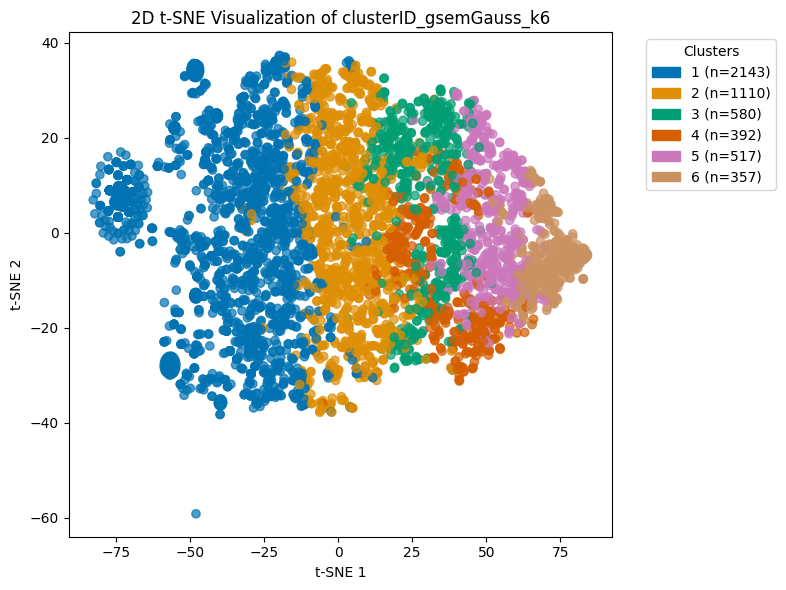

In [28]:
## Create Figure
if not debugmode: #skip if debugmode = True
    tSNE_2D = tSNE_2D(psaid12, describe_clusters, columns_gp, RandomSeed, custom_color_map, storefigures, figure_storage)
    tSNE_2D

In [29]:
#breakpoint()

#### Silhouette plot

In [53]:
def compute_silhouette_plot(data, columns_gp, cluster, custom_color_map, storefigures, figure_storage):
    """
    Function that calculates and plots the silhouette score for each cluster and their average score.
    It measures how similar an object is to its own cluster compared to other clusters.
    """ 
    print("""Cluster silhouette scores: \n 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned \n""")

    K = len(data[cluster].unique())
    cluster_assignment = data[cluster]
    
    ## Assign Colors
    colors = cluster_assignment.map(custom_color_map)
    
    # Create a subplot with 1 row and 2 columns
    fig, (ax1) = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)
    ax1.set_xlim([-1, 1])
    ax1.set_ylim([0, len(data) + (K + 1) * 10])   # The (k+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
    
    # Average Silhouette score for all samples.
    # This gives a perspective into the density and separation of the formed clusters
    silhouette_avg = silhouette_score(data[columns_gp], cluster_assignment) # Compute
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")  # Plot the vertical line for average silhouette score of all the values
    print(f' Average: {silhouette_avg}')
    
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(data[columns_gp], cluster_assignment)
    print(sample_silhouette_values.shape)

    y_lower = 10
    for i in np.sort(cluster_assignment.unique()):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        silhouette_values_i = sample_silhouette_values[cluster_assignment == i] # Subset
        silhouette_values_i.sort() #Sort values

        # Calculate average silhouette score of the cluster
        silhouette_avg_i = silhouette_values_i.mean()
        print(f' Average cluster {i}: {silhouette_avg_i}')

        # Calculate cluster size
        size_cluster_i = silhouette_values_i.shape[0]
        y_upper = y_lower + size_cluster_i

        # Format Colors
        spectral_palette = sns.color_palette("Spectral", K)
        color = color = custom_color_map[i] #spectral_palette #[spectral_palette[i] for i in desired_order_colors][i]
        
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            silhouette_values_i,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
    
        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.1, y_lower + 0.5 * size_cluster_i, f'{i} ({size_cluster_i})')
    
        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    # Format Graph
    ax1.set_title(f'The average silhouette_score is : {silhouette_avg}')
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks(np.arange(-1, 1.2, 0.2))
    
    plt.suptitle(f"Silhouette analysis for k = {cluster}", fontsize=14, fontweight="bold")
    if storefigures:
        plt.savefig(os.path.join(figure_storage, f'PsAID_{describe_clusters}_Silhouettes.png'))
    plt.show()

Cluster silhouette scores: 
 
        +1 = Good 
         0 = close to decision boundary 
        -1 = could be wrongfully assigned 

 Average: 0.26971362957415024
(5099,)
 Average cluster 1: 0.5027181001257914
 Average cluster 2: 0.0593599338486906
 Average cluster 3: 0.09440862239833275
 Average cluster 4: 0.07562445395278507
 Average cluster 5: 0.0860300825991888
 Average cluster 6: 0.2890085221643398


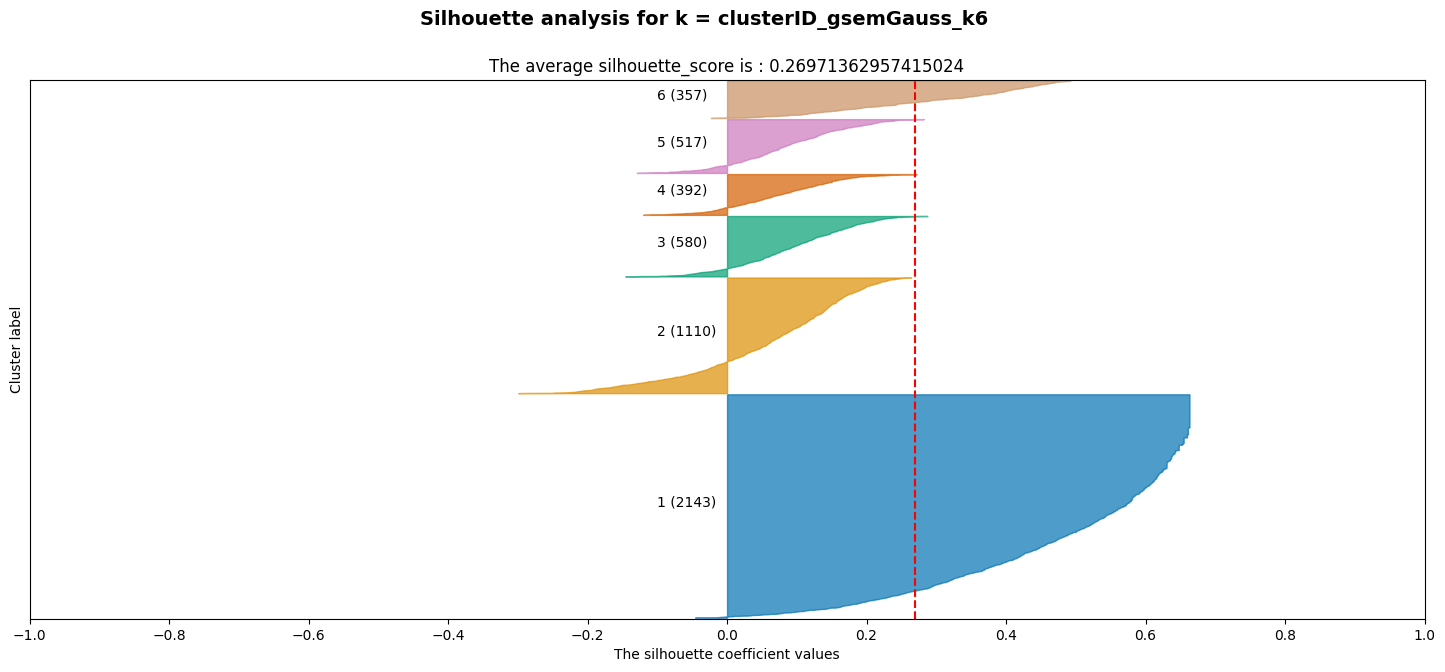

In [54]:
compute_silhouette_plot(psaid12[columns_gp + [describe_clusters]], columns_gp, describe_clusters, custom_color_map, storefigures, figure_storage)


#### Pair Plot Heatmap

In [30]:
def pairplot_heatmap(data, varlist, describe_clusters, dictionary, custom_color_map, storefigures, figure_storage): 
    """
    Function that creates a plair plot of the various variables against each other.
    The diagonal shows the KDE
    The colors indicate the assigned clusters
    The hues indicate the density of datapoints in a certain place 

    Before running this function make sure that your clusters have the desired_layer_order
    """
    clusters = np.sort(data[describe_clusters].unique())

    # Order clusters by WCSS for plotting
    cluster_sizes = data[describe_clusters].value_counts()
    cluster_variances = (data.groupby(describe_clusters)[varlist].var().sum(axis=1))  # total variance per cluster
    layer_order = cluster_variances.sort_values().index.tolist() # most compact drawn on top
    
    # Create Pairplot
    pp = sns.pairplot(data[varlist + [describe_clusters]], hue=describe_clusters, hue_order = layer_order[::-1], corner=True, diag_kind='kde', palette=custom_color_map)
    pp.map_lower(sns.kdeplot, levels = 8, shade=True, alpha=0.6, legend = False) #Add filled contours
   # pp.fig.set_size_inches(24, 20)

    # Format axes
    for i, j in zip(*np.tril_indices_from(pp.axes, k=-1)):  # Loop only through the lower triangle
         if pp.axes[i, j] is not None:
            x_label = '\n'.join(textwrap.wrap(dictionary[varlist[j]], width=20))
            y_label = '\n'.join(textwrap.wrap(dictionary[varlist[i]], width=20))
            pp.axes[i, j].set_xlabel(x_label, labelpad=10, fontsize=15)
            pp.axes[i, j].set_ylabel(y_label, labelpad=10, fontsize=15)
            pp.axes[i, j].set(xlim=(0,10), ylim = (0,10))

    # Add legend
    legend_handles = []
    for label, color in custom_color_map.items():
        size = cluster_sizes.get(label, 0)  # default 0 if missing
        legend_label = f"{label} (n={size})"
        patch = mpatches.Patch(color=color, label=legend_label)
        legend_handles.append(patch)
    pp._legend.remove()  # Remove Seaborn’s auto-legend
    
    pp.fig.legend(
        handles=legend_handles,
        title="Clusters",
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        frameon=True,
        fontsize=15
        )

    # Print & store figure
    plt.tight_layout()
    pp.fig.suptitle(f'PsAID clustering, {describe_clusters}', y=1.02, fontsize=35)
    if storefigures:
        pp.savefig(os.path.join(figure_storage, f'PsAID_{describe_clusters}_KDEHeatmap.png'))
    plt.show() 

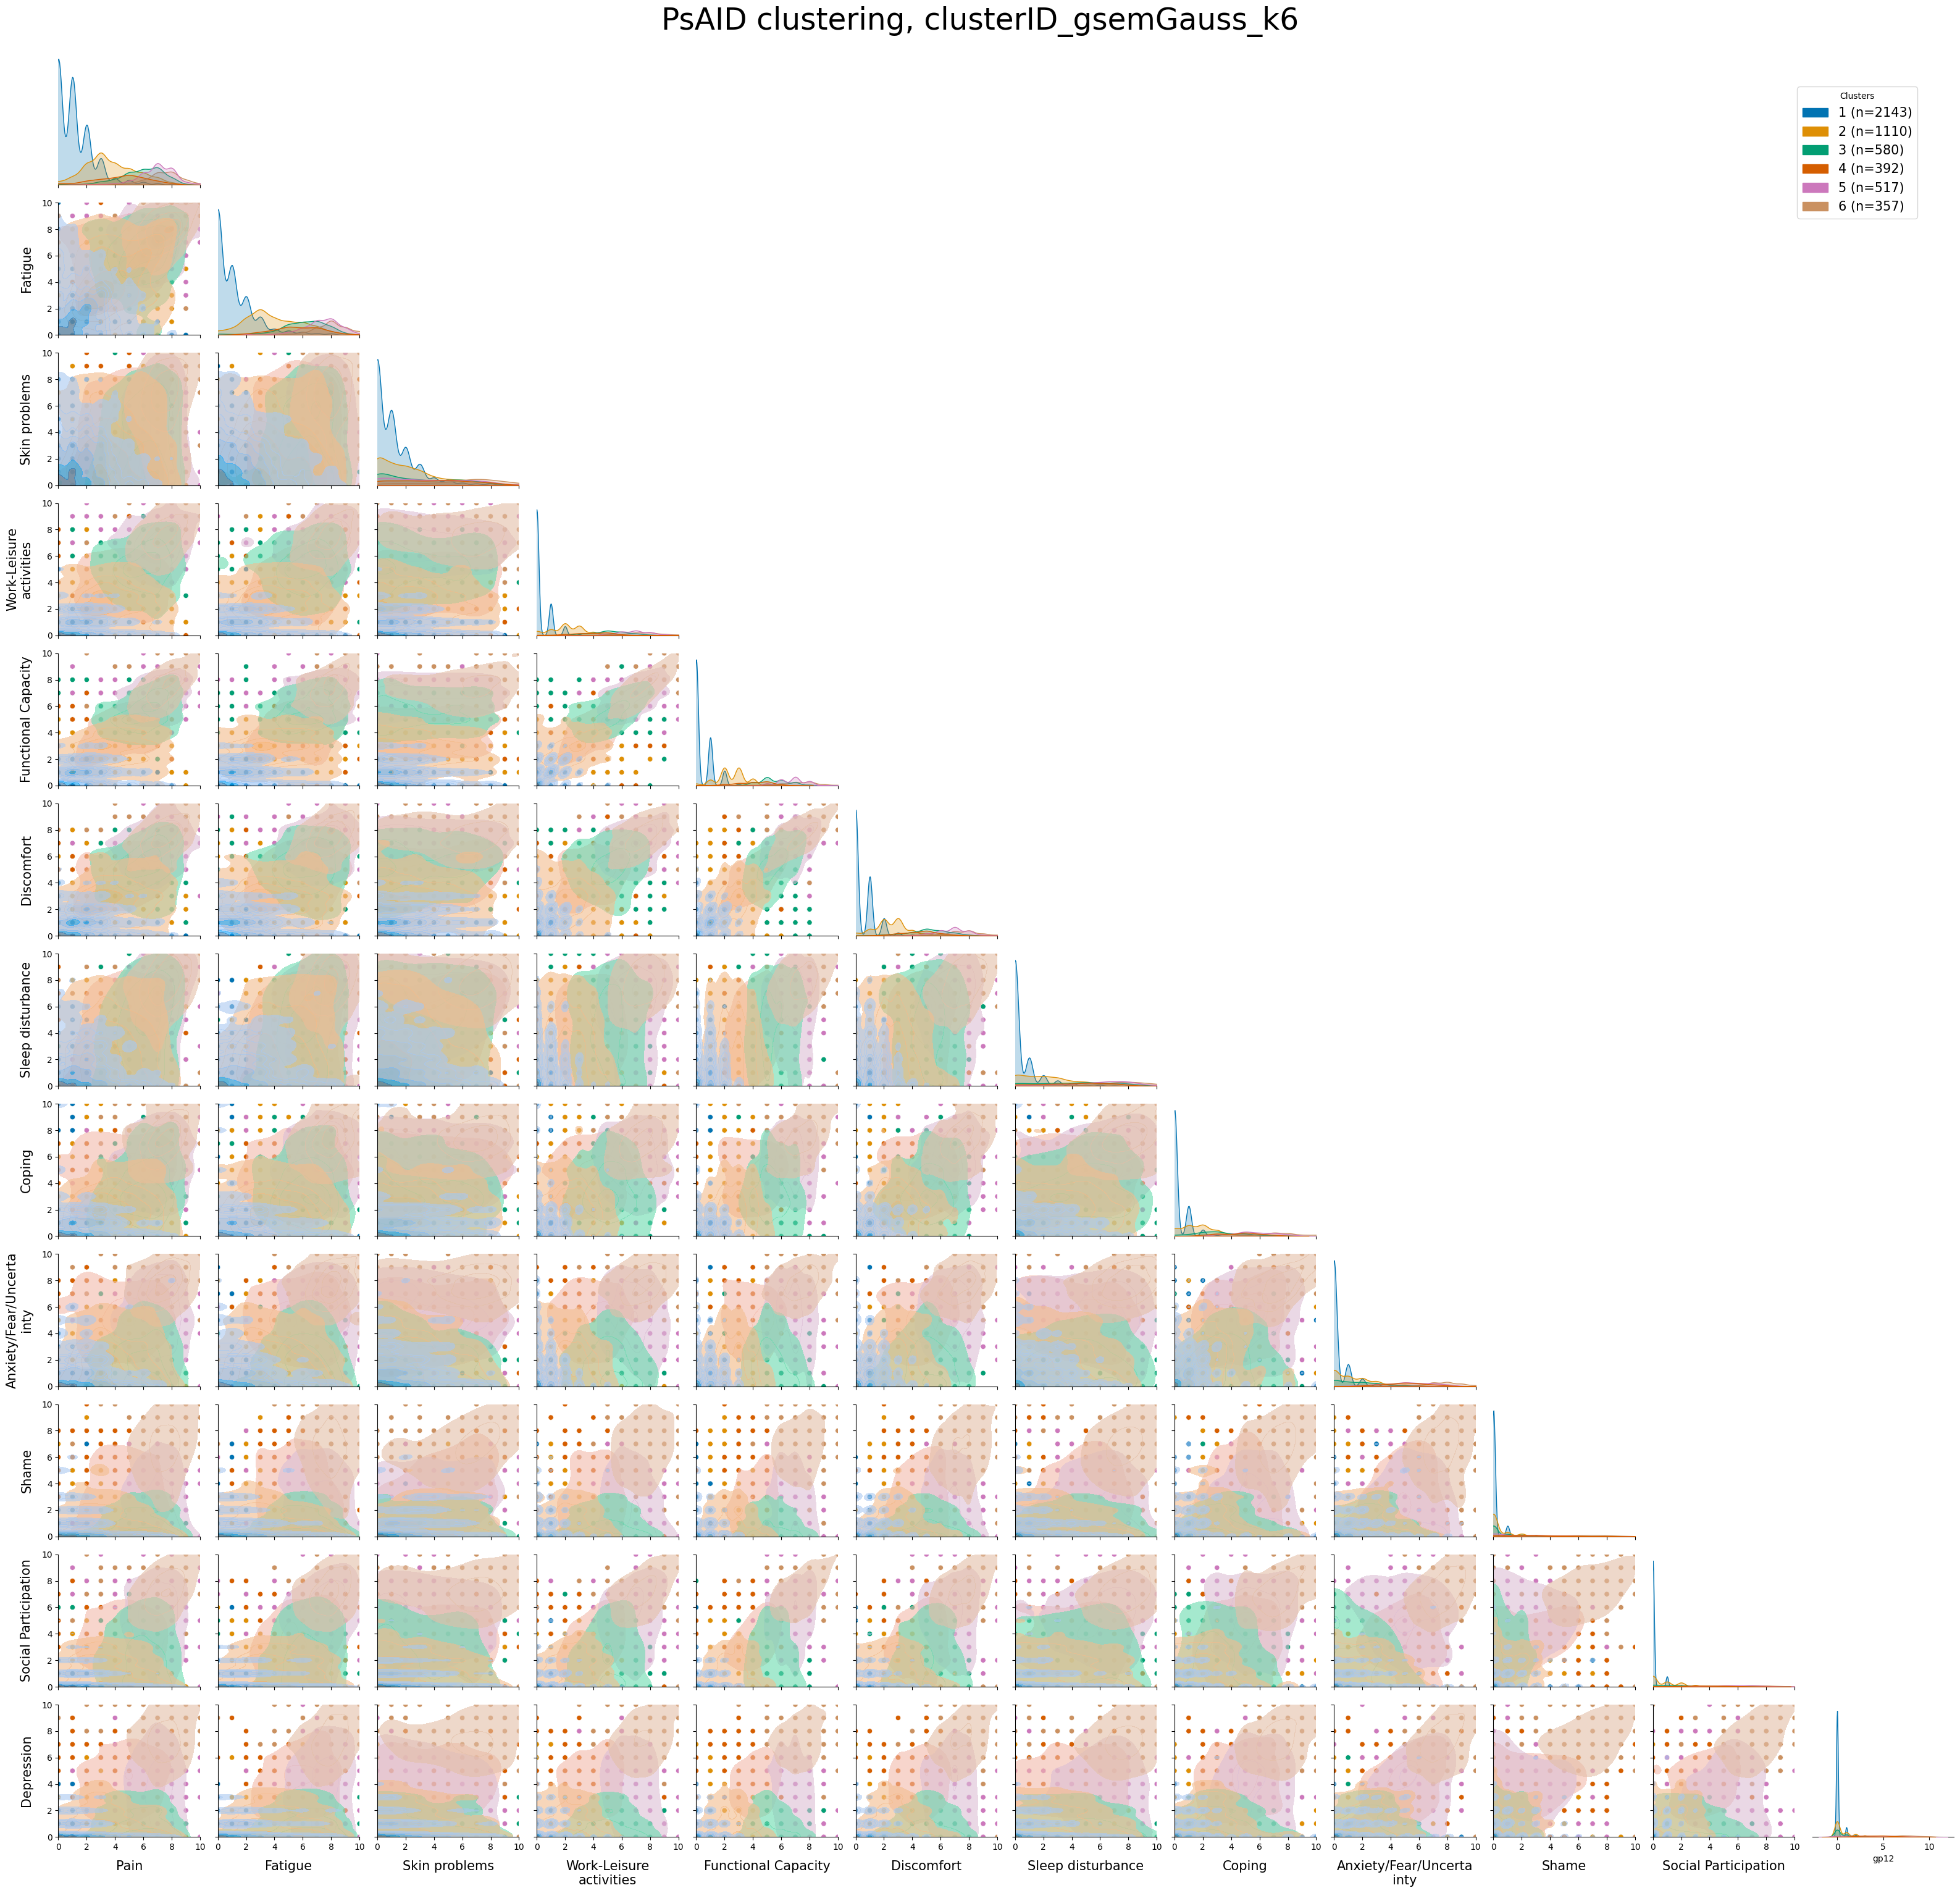

In [31]:
## Create Figure
if not debugmode: #skip if debugmode = True
    if not skip_pairplot: #skip if skip_pairplot = True
        pairplot_heatmap(psaid12, columns_gp, describe_clusters, domains_dict, custom_color_map, storefigures, figure_storage)

#### Variable Heatmap

In [35]:
def plot_heatmap(data, describe_clusters, varlist, dictionary, figsize=(12, 8), cmap='vlag'):
    """
    This function generates a heatmap of variable scores. Datapoints are sorted based on 1) cluster, 2) Total PsAID Score. 
    """
    
    # Sort data by cluster ID
    sorted_data = data.sort_values(by=[describe_clusters, 'psaid12'], ascending=[True, False]).reset_index(drop=True)
    clusters = sorted_data[describe_clusters].values

    # Identify where cluster IDs change (i.e., where to draw lines)
    separator_indices = np.where(np.diff(clusters) != 0)[0] + 1

    ytick_labels = [''] * len(clusters)  # Initialize empty labels
    
    # Find the middle row of each cluster
    cluster_indices = np.where(np.diff(clusters) != 0)[0] + 1  # Indices where clusters change
    start_idx = 0  # Start index of the first cluster

    for end_idx in cluster_indices.tolist() + [len(clusters)]:  # Add last index
        middle_idx = (start_idx + end_idx) // 2  # Find middle index
        ytick_labels[middle_idx] = f'Cluster {clusters[start_idx]}'  # Set cluster ID in the middle row
        start_idx = end_idx  # Move to the next cluster

    # Plot heatmap
    plt.figure(figsize=figsize)
    ax = sns.heatmap(sorted_data[varlist], vmin = 0, vmax = 10, cmap=cmap, center=0, yticklabels=ytick_labels, cbar_kws={'label': 'PsAID Value'})
    plt.title(f"Heatmap of the PsAID Domains per unique observational unit. Units are sorted by ClusterID & Total PsAID Score \n ({describe_clusters})")
    
    # Replace x-axis labels for both subplots with dictionary names
    current_labels = ax.get_xticklabels() # Get current x-axis tick labels
    new_labels = [dictionary[label.get_text()] for label in current_labels] # Map using the dictionary
    ax.set_xticklabels(new_labels, rotation=45, ha='right') # Apply new labels with rotation

    # Add thick black lines at the cluster boundaries
    for sep in separator_indices:
        ax.hlines(sep, *ax.get_xlim(), colors='black', linewidth=2)

    plt.tight_layout()
    plt.savefig(os.path.join(figure_storage, f'PsAID_{describe_clusters}_Heatmap_PsaidScores.png'))
    plt.show()

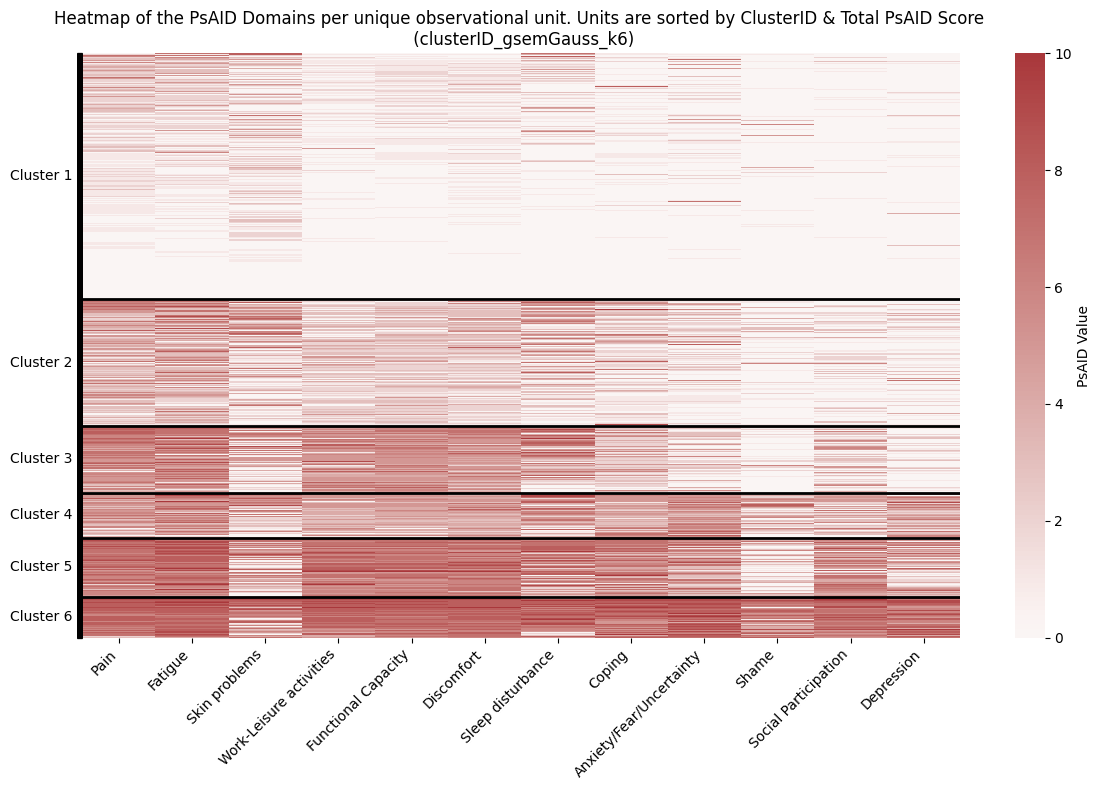

In [36]:
if not debugmode: #skip if debugmode = True
    plot_heatmap(psaid12, describe_clusters, columns_gp, domains_dict)

#### Deviation from the Mean

##### By PsAID Domain

                            gp01      gp02      gp03      gp04      gp05  \
clusterID_gsemGauss_k6                                                     
1                      -2.341936 -2.604071 -1.218369 -2.368441 -2.419631   
2                       0.174248  0.183812 -0.126713 -0.488812 -0.318402   
3                       2.327137  2.275300  0.482110  2.321223  2.560333   
4                       0.927295  1.898171  1.438584  1.163675  1.104897   
5                       3.383286  3.505561  1.220835  4.093149  3.889077   
6                       3.817801  4.202693  3.576740  4.760564  4.509609   

                            gp06      gp07      gp08      gp09      gp10  \
clusterID_gsemGauss_k6                                                     
1                      -2.392247 -2.118758 -2.012461 -1.731844 -0.974460   
2                      -0.323116 -0.232594 -0.485584 -0.660380 -0.561913   
3                       2.115871  1.527409  0.898216 -0.379330 -0.547700   
4          

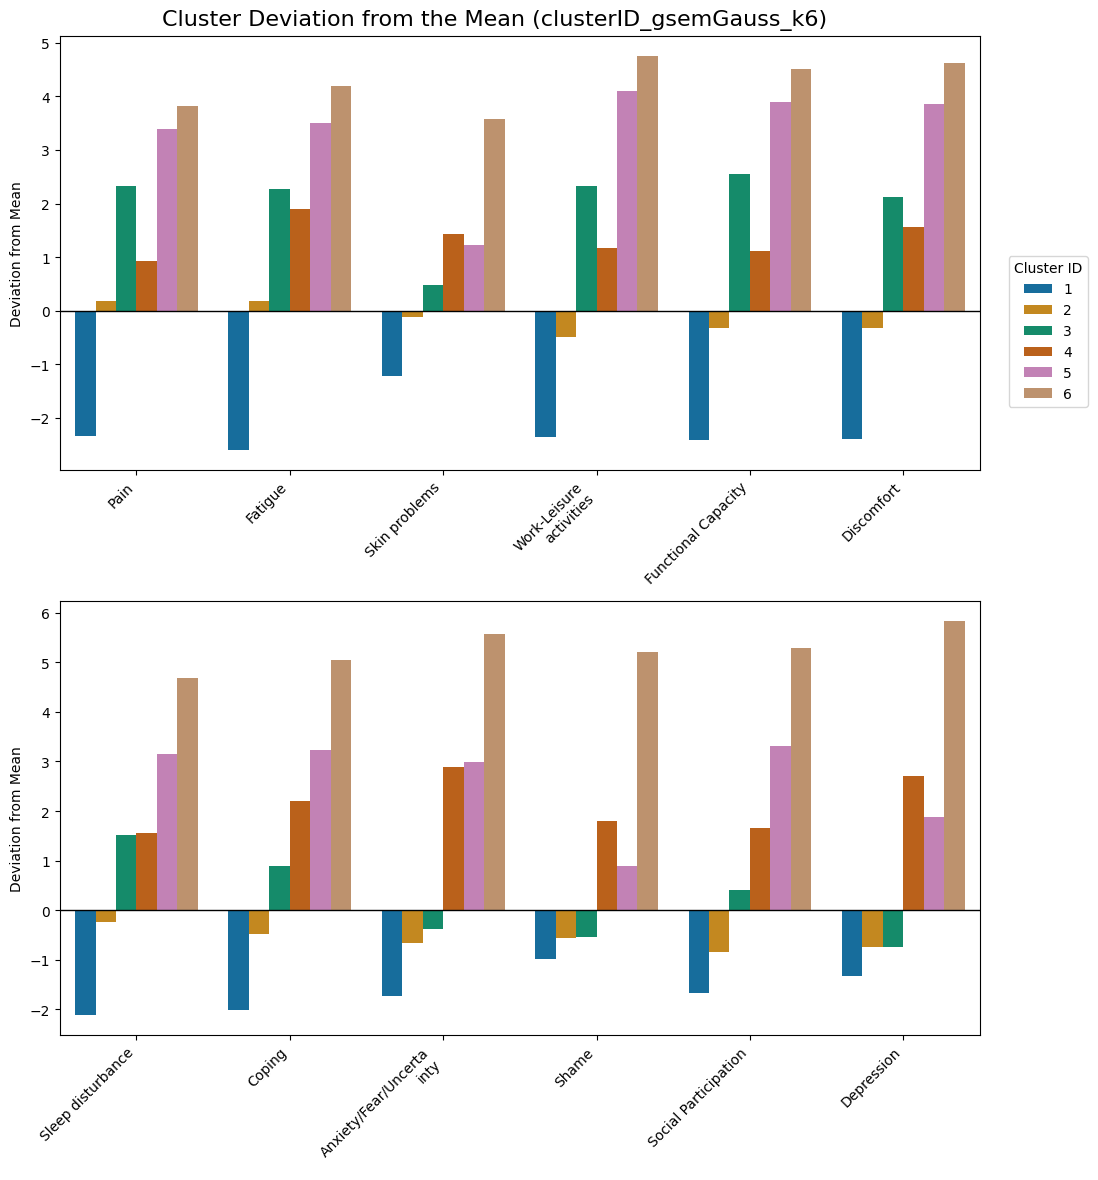

In [37]:
if not debugmode: #skip if debugmode = True
    ## Compute Deviation from the Mean for each variable per cluster
    deviation_from_mean = cluster_stats.xs('mean', axis=1, level=1).sub(complete_stats['mean'], axis=1)
    print(deviation_from_mean)
    
    # Reshape the DataFrame for plotting
    deviation_long = deviation_from_mean.reset_index().melt(
        id_vars=describe_clusters,  # Keep the cluster ID as an identifier
        value_vars=columns_gp,  # Variables to plot
        var_name="Variable",  # Name for the variable column
        value_name="Deviation"  # Name for the deviation values
    )
    
    # Plot all variables in one figure
    # Initiate figure and define subfigures
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))  # Two rows, one column
    
    # plt.figure(figsize=(10, 6))  # Set figure size
    
    # First Subplot gp01-gp06
    sns.barplot(
        data=deviation_long[deviation_long["Variable"].isin(columns_gp[:6])],
        x="Variable",    # Variables on x-axis
        y="Deviation",   # Deviation values on y-axis
        hue=describe_clusters,  # Different colors for each cluster
        palette=custom_color_map, #Define colors
        ax = axes[0]
    )
    
    # Format subplot 1
    axes[0].set_xlabel("") 
    axes[0].axhline(0, color='black', linewidth=1) # Plot Horizontal line at 0
    axes[0].set_ylabel("Deviation from Mean")
    axes[0].legend().set_visible(False)
    
    # Second Subplot gp07-gp12
    # First Subplot gp01-gp06
    sns.barplot(
        data=deviation_long[deviation_long["Variable"].isin(columns_gp[6:])],
        x="Variable",    # Variables on x-axis
        y="Deviation",   # Deviation values on y-axis
        hue=describe_clusters,  # Different colors for each cluster
        palette=custom_color_map, #Define colors
        ax = axes[1]
    )
    
    # Format subplot 2
    axes[1].set_xlabel("") 
    axes[1].axhline(0, color='black', linewidth=1) # Plot Horizontal line at 0
    axes[1].set_ylabel("Deviation from Mean")
    axes[1].legend().set_visible(False)
    
    # Replace x-axis labels for both subplots with dictionary names
    for ax in axes:
        current_labels = ax.get_xticklabels() # Get current x-axis tick labels
        new_labels = [domains_dict[label.get_text()] for label in current_labels] # Map using the dictionary
        new_labels = ['\n'.join(textwrap.wrap(label, width=20)) for label in new_labels]
        ax.set_xticklabels(new_labels, rotation=45, ha='right') # Apply new labels with rotation
    
    # Adjust legend placement
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Cluster ID",
        loc='upper right',
        bbox_to_anchor=(1.1, 0.78), # Specify Position
        ncol=1 # Arrange items in a single column
    )
    
    fig.suptitle(f'Cluster Deviation from the Mean ({describe_clusters})', fontsize=16)
    plt.tight_layout()  # Adjust layout for better fit
    plt.savefig(os.path.join(figure_storage,f'PSAID_{describe_clusters}_Cluster Deviation from the Mean.png'), bbox_inches='tight')
    
    # Show plot
    plt.show()

#### Boxplot by PsAID Domains

In [38]:
def plot_boxplot_byvars(data, varlist, cluster_assignment, dictionary, custom_palette, storefigures, limits):
        
    #Initialize Figure
    fig, axes = plt.subplots(ncols=3, nrows=round(np.ceil(len(varlist)/3)), figsize=(30,30)) #Set up a figure grid of subplots
    
    # ncols = math.ceil(math.sqrt(len(varlist)))      # First, define columns
    # nrows = math.ceil(len(varlist) / ncols)         # Then define rows based on columns
    # fig, axes = plt.subplots(ncols = ncols, nrows = nrows, figsize=(30,30))
    
    axes = axes.flatten() #Number subplots, ignore colums

    # Plot histogram with density for each variable
    for i, col in enumerate(varlist): #Loop over variables
        if limits is None:
            ylim = data[varlist].iloc[:,0].max() + 1
        else:
            ylim = limits.get(col, data[col].max())
        
        sns.boxplot(x=cluster_assignment, y=col, data=data, ax=axes[i], palette=custom_palette)
        #Format plots
        axes[i].set_title(f'Score of question {col} - {dictionary[col]}')
        axes[i].set_ylabel(f'{col}')
        axes[i].set_xlabel('ClusterID')
        axes[i].set_ylim(0, ylim)
        # Hide any extra axes
        
    for j in range(len(varlist), len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f'Boxplot by {cluster_assignment}', fontsize=20)
    if storefigures == True: 
        if varlist[0].startswith('gp'):
            plt.savefig(os.path.join(figure_storage, f'PsAID_{cluster_assignment}_Boxplot_PsaidScores.png'))
        else : 
            plt.savefig(os.path.join(figure_storage, f'PsAID_{cluster_assignment}_Boxplot_ClinicalVars.png'))        
    plt.show()

In [39]:
math.sqrt(len(clinical_variables))

2.6457513110645907

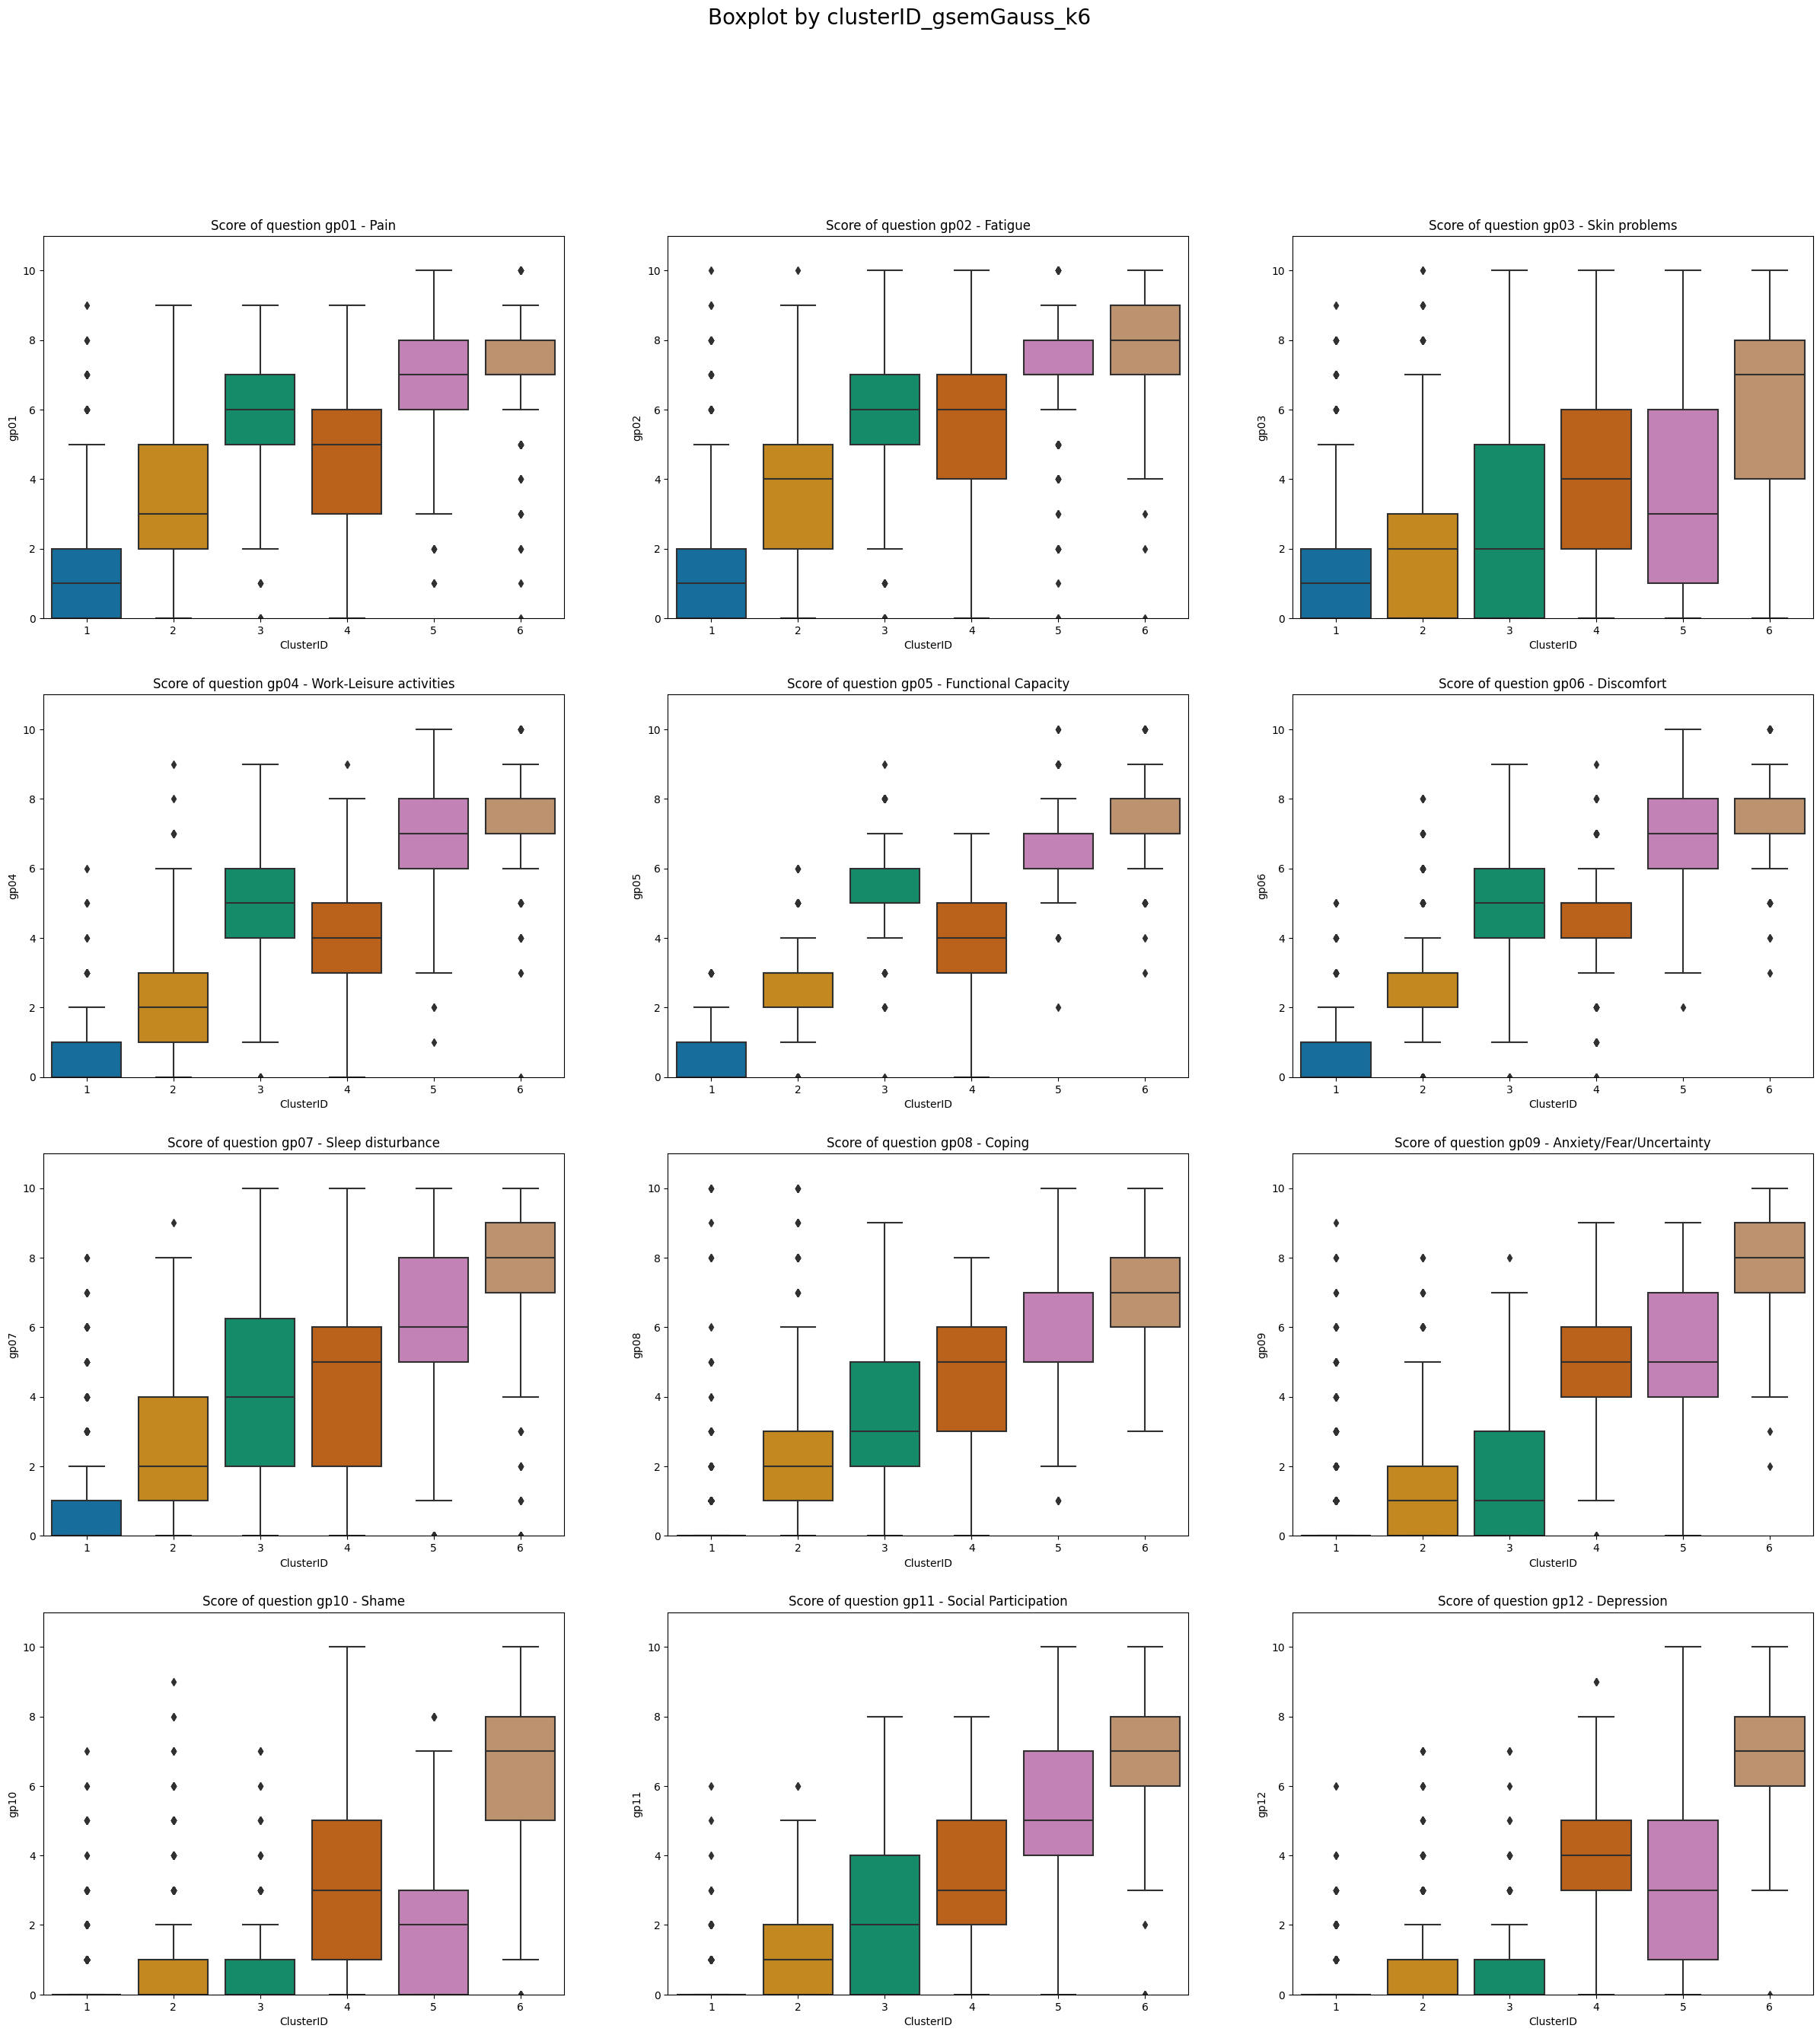

In [40]:
if not debugmode: #skip if debugmode = True
    plot_boxplot_byvars(psaid12, columns_gp, describe_clusters, domains_dict, custom_palette, storefigures, limits = None)

#### Boxplot by Cluster

In [41]:
def plot_boxplot_bycluster(data, varlist, cluster_assignment, dictionary, custom_palette, storefigures, limits):
    
    # Define Figure Grid
    clusters = np.sort(data[cluster_assignment].unique())
    n_clusters = len(clusters)
    cols = min(3, n_clusters)
    rows = math.ceil(n_clusters / cols)

    # Define Font Sizes
    title_fs = 18
    axis_label_fs = 14
    tick_fs = 11
    suptitle_fs = 22
    
    #Initialize Figure
    fig, axes = plt.subplots(ncols=rows, nrows=cols, figsize=(cols*3.4,rows*6)) #Set up a figure grid of subplots  
    axes = axes.flatten() #Number subplots, ignore colums

    # Plot histogram with density for each cluster
    for i, c in enumerate(clusters): #Loop over clusters
        cluster_data = data[data[cluster_assignment] == c][varlist].copy()

        # Reshape for Seaborn boxplot
        long_data = cluster_data.melt(var_name='Variable', value_name='Score')
        
        # Map variable names to dictionary labels
        long_data['Variable'] = long_data['Variable'].map(dictionary)

        # Background severity bands
        if c in [1, 2]:
            axes[i].axhspan(0, 3, alpha=0.12, zorder=0)
        elif c in [3, 4]:
            axes[i].axhspan(3, 5, alpha=0.12, zorder=0)
        elif c in [5, 6]:
            axes[i].axhspan(5, 8, alpha=0.12, zorder=0)

        # Plot
        sns.boxplot(data=long_data, x='Variable', y='Score', ax=axes[i], color=custom_palette[c-1])
        axes[i].set_title(f'Cluster {c}', fontsize=title_fs)
        axes[i].set_ylabel('Score', fontsize=axis_label_fs)
        axes[i].set_xlabel("")
        axes[i].tick_params(axis='both', labelsize=tick_fs)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_xticklabels(axes[i].get_xticklabels(), ha='right')

        # # Only show x labels on bottom row
        # if i < 4:
        #     axes[i].set_xticklabels([])
        #     axes[i].set_xlabel("")
        # else:
        #     axes[i].tick_params(axis='x', rotation=45)
        # axes[i].set_xticklabels(axes[i].get_xticklabels(), ha='right')

    # Remove any unused subplot
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    #fig.suptitle(f'Boxplot of variables per cluster ({cluster_assignment})', fontsize=suptitle_fs)
    #plt.tight_layout(rect=[0, 0, 0.96, 1])
    plt.tight_layout() #rect=[0, 0.1, 0.5, 1.1]
    if storefigures:
        if varlist[0].startswith('gp'):
            plt.savefig(os.path.join(figure_storage, f'PsAID_{cluster_assignment}_Boxplot_PsaidScoresbycluster.png'))
        else : 
            plt.savefig(os.path.join(figure_storage, f'PsAID_{cluster_assignment}_Boxplot_ClinicalVarsbycluster.png'))        
    plt.show()


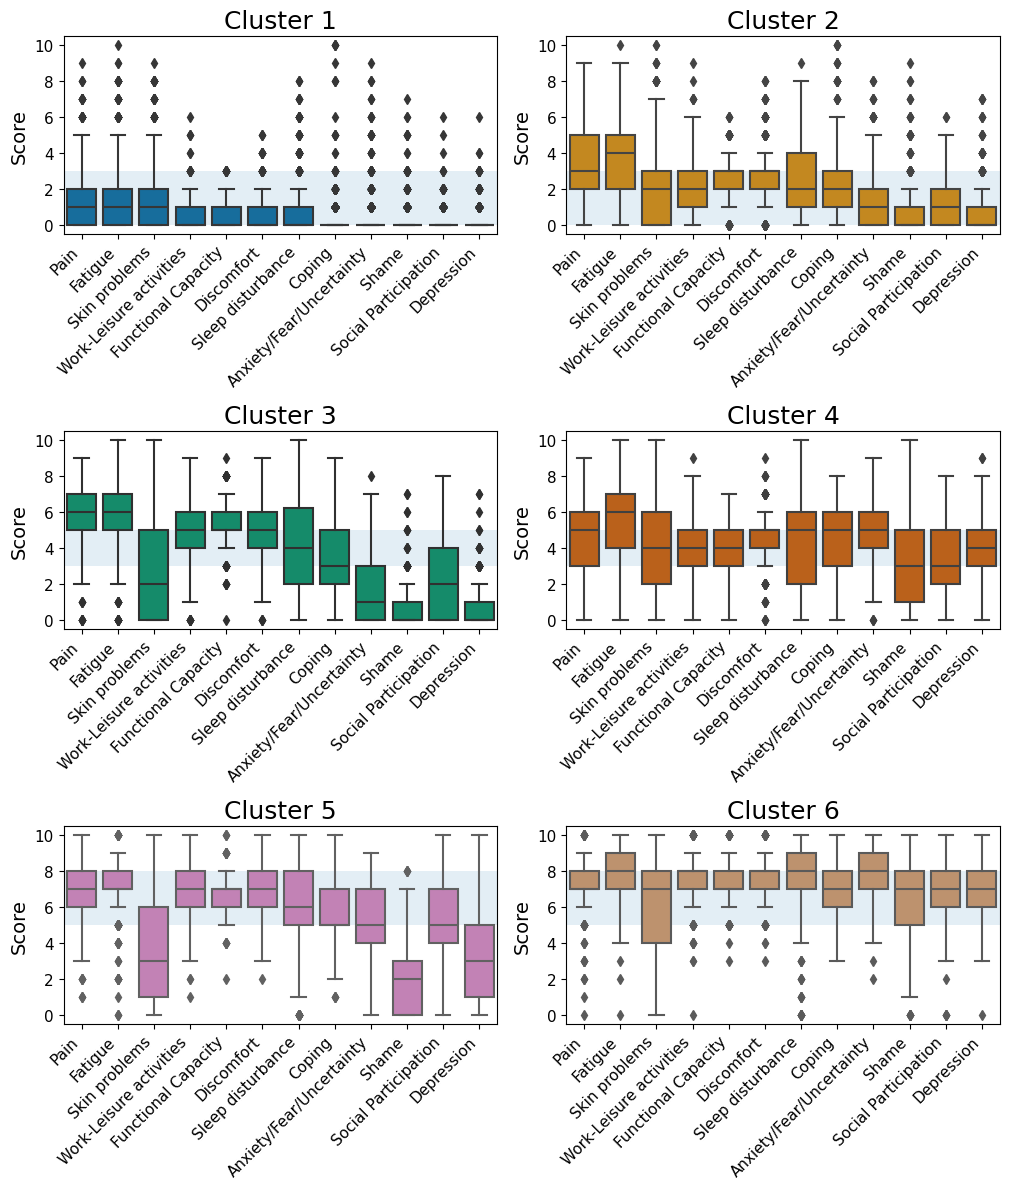

In [42]:
if not debugmode: #skip if debugmode = True
    plot_boxplot_bycluster(psaid12, columns_gp, describe_clusters, domains_dict, custom_palette, storefigures, limits = None)

In [43]:
def plot_violin_bycluster(data, varlist, cluster_assignment, dictionary, custom_palette, storefigures, limits):

    clusters = np.sort(data[cluster_assignment].unique())
    n_clusters = len(clusters)
    cols = min(3, n_clusters)
    rows = math.ceil(n_clusters / cols)

    fig, axes = plt.subplots(ncols=cols, nrows=rows, figsize=(cols*6, rows*6))
    axes = axes.flatten()

    for i, c in enumerate(clusters):
        cluster_data = data[data[cluster_assignment] == c][varlist].copy()
        long_data = cluster_data.melt(var_name='Variable', value_name='Score')
        long_data['Variable'] = long_data['Variable'].map(dictionary)

        # --- VIOLIN PLOT INSTEAD OF BOXPLOT ---
        sns.violinplot(
            data=long_data,
            x='Variable',
            y='Score',
            ax=axes[i],
            palette=[custom_palette[c-1]],
            cut=0,
            inner='box'
        )

        axes[i].set_title(f'Cluster {c}')
        axes[i].set_ylabel('Score')
        axes[i].set_xlabel("")
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_xticklabels(axes[i].get_xticklabels(), ha='right')

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'Violin plot of variables per cluster ({cluster_assignment})', fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if storefigures:
        if varlist[0].startswith('gp'):
            plt.savefig(os.path.join(figure_storage, f'PsAID_{cluster_assignment}_Violin_PsaidScoresbycluster.png'))
        else:
            plt.savefig(os.path.join(figure_storage, f'PsAID_{cluster_assignment}_Violin_ClinicalVarsbycluster.png'))

    plt.show()


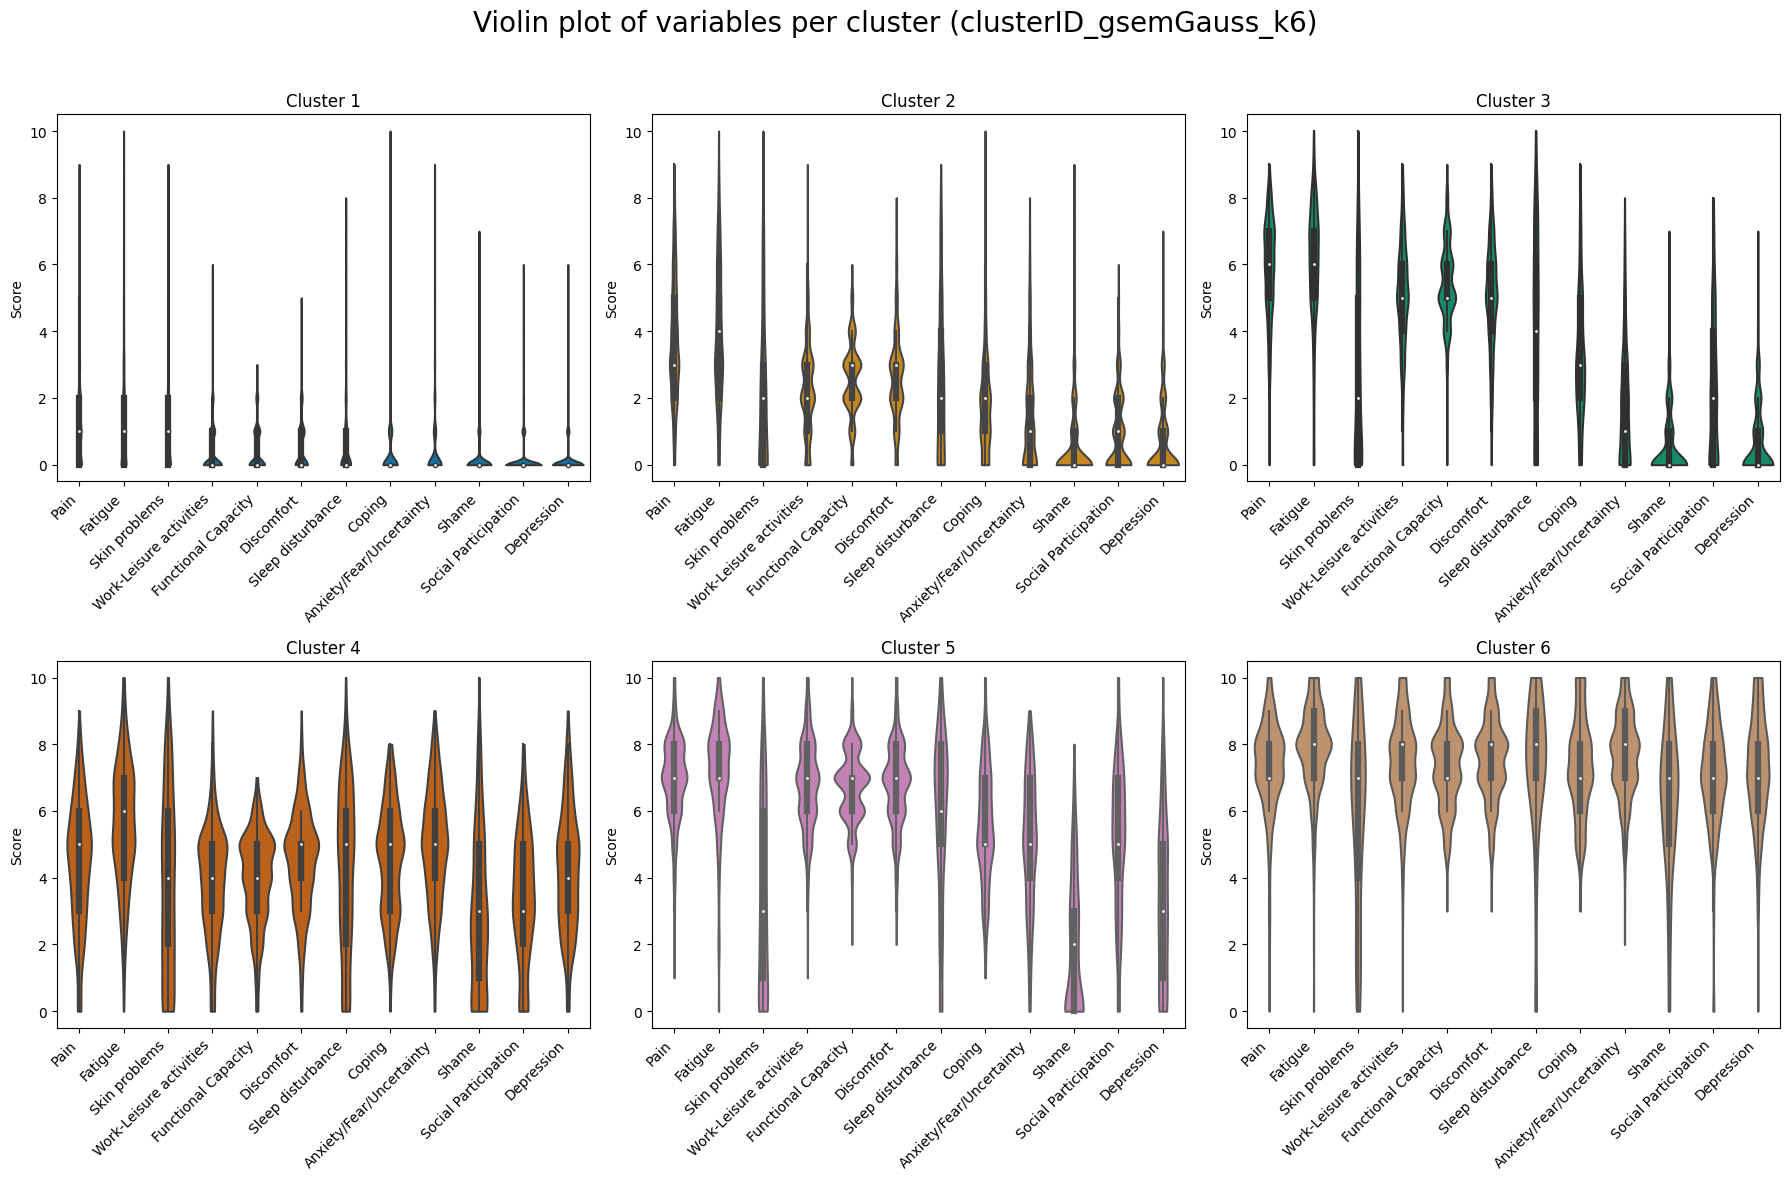

In [44]:
if not debugmode: #skip if debugmode = True
    plot_violin_bycluster(psaid12, columns_gp, describe_clusters, domains_dict, custom_palette, storefigures, limits = None)

#### Spider Chart / Radial Chart

In [45]:
# Variables and example data
def plot_radar_chart_PsAID(cluster_assignment, varlist, cluster_medians, cluster_size, domains_dict, custom_palette, storefigures):

    # Set up the radar chart axes
    angles = np.linspace(0, 2 * np.pi, len(varlist), endpoint=False).tolist()
    angles += angles[:1]  # Close the circle
    # print(f' ANgles: {len(angles)}')

    # Define Figure Grid
    num_clusters = cluster_stats.shape[0]
    cols = min(3, num_clusters)
    rows = math.ceil(num_clusters / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6), subplot_kw=dict(polar=True))
    axes = axes.flatten()

    # Repeat the first value to close the circular plot
    cluster_medians += cluster_medians[:1]
    # print(f'Medians: {cluster_medians.shape}')

    # Plot the means for each cluster 
    for cluster in range(num_clusters):
        ax = axes[cluster] # Select suplot in Figure grid

        # Plot values
        values = cluster_stats.xs('median', axis=1, level=1)[varlist].iloc[cluster].tolist()
        values += values[:1]  # Close the loop by repeating the first value
        ax.plot(angles, values, label=f'Cluster {cluster} (n={cluster_size[cluster]})', linewidth=2, linestyle='solid', color=custom_palette[cluster]) # Plot perimeter
        ax.fill(angles, values, alpha=0.25, color = custom_palette[cluster]) # Fill perimeter

        # Customize the chart
        ax.set_title(f'Cluster {cluster} (n={cluster_size[cluster]})', size=15, va='bottom')
        ax.set_yticks(np.arange(0, 11, 2))
        ax.set_ylim(0, 10)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([domains_dict[label] for label in varlist], size=8) #Replace labels as specified in the dictionary with PsAID Domains
        # Make sure the labels do not overlap with the figure by aligning them properly
        for label, angle in zip(ax.get_xticklabels(), angles):
            angle_deg = np.degrees(angle)
            if angle_deg < 90 or angle_deg > 270:        # If text on the leftside of the circle
                label.set_horizontalalignment('left')    # Align text left
            elif angle_deg == 90 or angle_deg == 270:    # If text top or bottom of the circle
                label.set_horizontalalignment('center') # Align text Middle
            else:                                        # Else, if text on rightside of the circle
                label.set_horizontalalignment('right')   # Align text right

    # # Hide unused subplots
    for i in range(num_clusters, len(axes)):
        fig.delaxes(axes[i])

    # Display the plot
    fig.suptitle(f'Radar Chart of Clinical PsAID Domain Medians by {cluster_assignment}', size=20, va='bottom')
    plt.tight_layout()
    if storefigures: 
        plt.savefig(os.path.join(figure_storage, f'PsAID_{cluster_assignment}_Radar by PsAID Domain Medians.png'))
    plt.show()

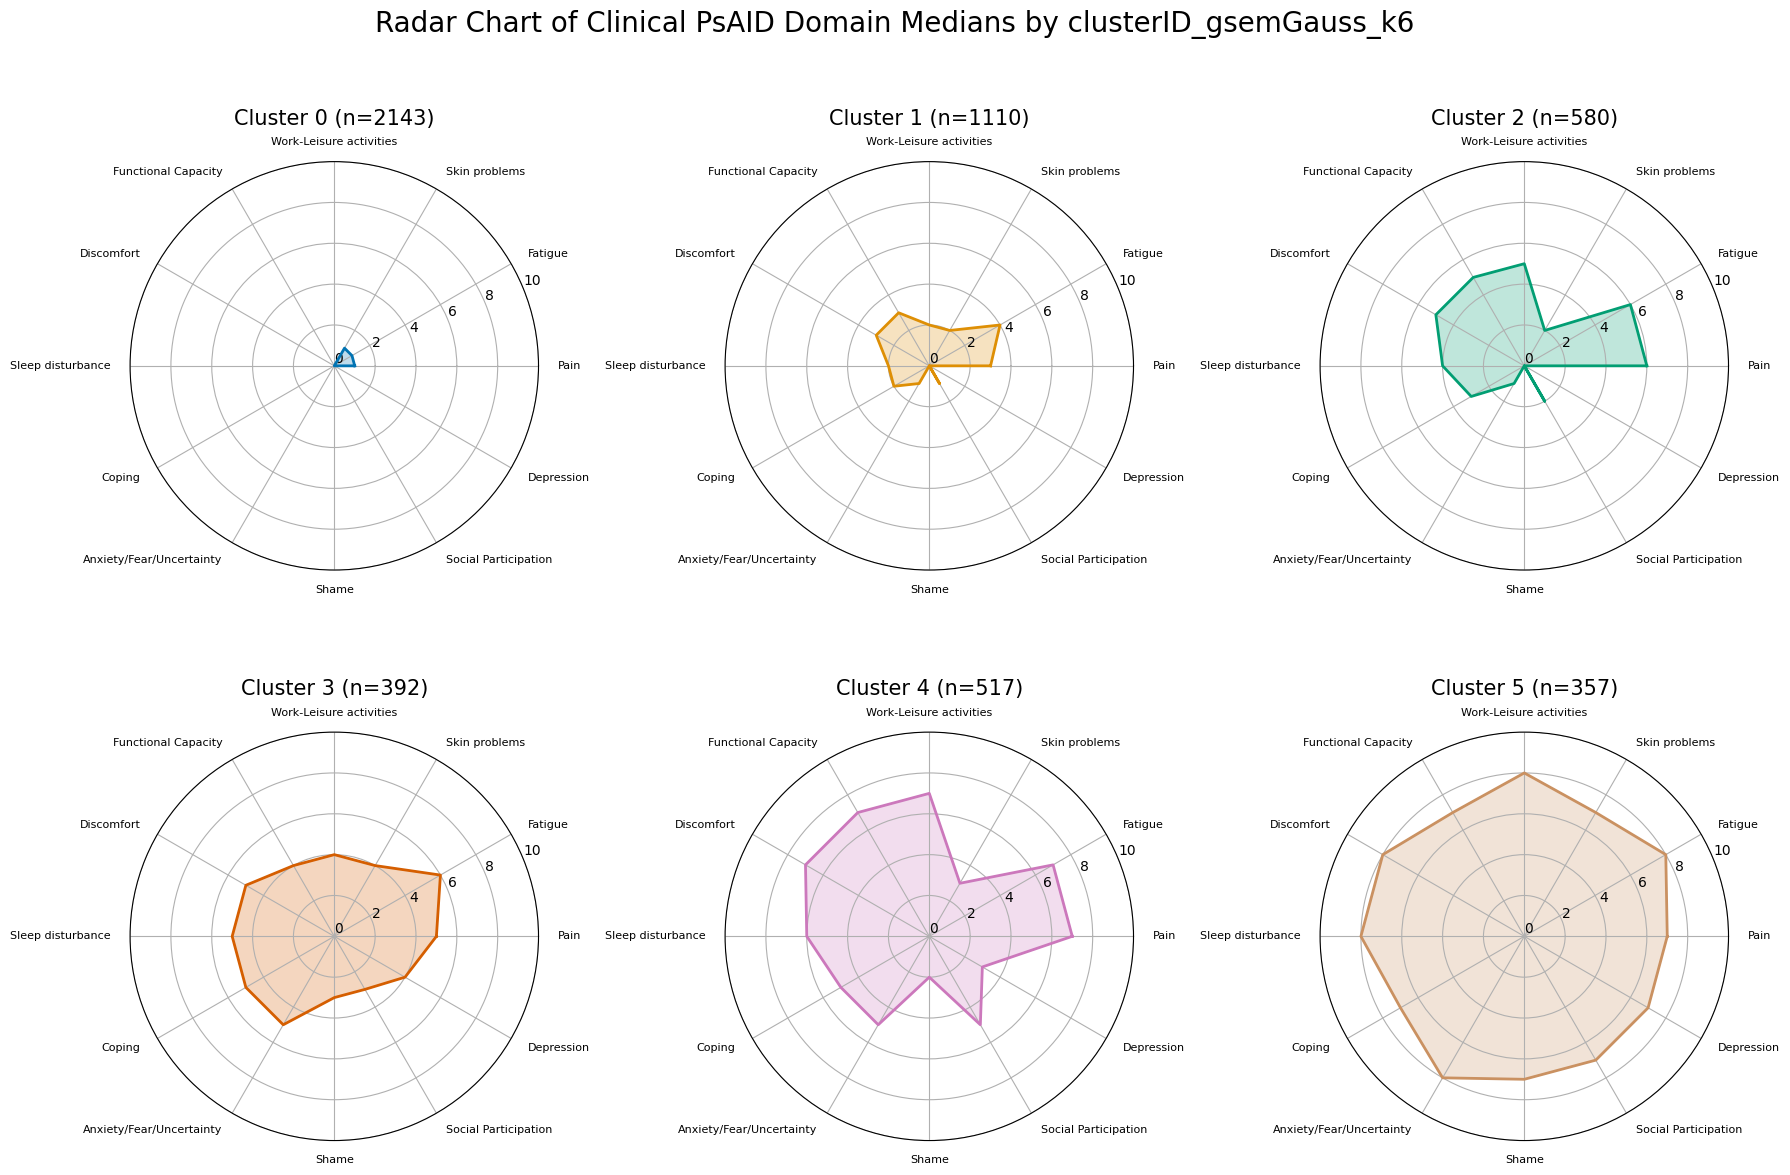

In [46]:
if not debugmode: #skip if debugmode = True
    plot_radar_chart_PsAID(describe_clusters, columns_gp, cluster_stats.xs('median', axis=1, level=1), cluster_size, domains_dict, custom_palette, storefigures)

### By Clinical Variables

#### Descriptive Table

Median + IQR for continuous variables

In [47]:
# Generate the table with mean and std for each cluster and the complete dataset
cluster_stats_cv, complete_stats_cv, cluster_stats_table_cv = calc_cluster_stats(data_complete, describe_clusters, ['age', 'bmi', 'pm86b'] + clinical_variables + composite_scores)

folder_path = data_storage
if by_algorithm:
    file_name = f'PsAID_{algorithm}_ClusterStats_{describe_clusters}'
if selected_solutions:
    file_name = f'PsAID_ClusterStats_{describe_clusters}'
    
# Ensure the folder exists
os.makedirs(folder_path, exist_ok=True)

# Save
cluster_stats_cv.to_csv(f'{folder_path}/{file_name}.csv', index=False)
print(f' Dataset saved to {folder_path}/{file_name}.csv')

cluster_stats_cv

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Selected Clustering Solutions/PsAID_clusterID_gsemGauss_k6/PsAID_ClusterStats_Psaid_clusterID_gsemGauss_k6.csv
 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Selected Clustering Solutions/PsAID_clusterID_gsemGauss_k6/PsAID_ClusterStats_clusterID_gsemGauss_k6.csv


age                                      bmi  \
                             mean        std median IQR  Q1  Q3       mean   
clusterID_gsemGauss_k6                                                       
1                       52.354176  13.277055   54.0  20  43  63  28.485899   
2                       51.052252  13.590659   52.0  20  42  62  29.115204   
3                       51.758204  12.220448   52.0  18  43  61  30.753863   
4                       48.621483  13.661473   51.0  19  40  59  29.750482   
5                       48.303502  13.086804   50.0  21  37  58  28.721114   
6                       46.616246   13.23517   49.0  21  35  56  29.940406   

                                                        ...    pasdas  \
                              std     median       IQR  ...    median   
clusterID_gsemGauss_k6                                  ...             
1                       15.594484  26.869271  6.230665  ...  1.957851   
2                       11.329249  28.235752  7.112289  ...  3.055806   
3                       12.413739  29.761906  7.499234  ...  4.011483   
4                       12.626902  28.075043  6.875909  ...  3.564319   
5                        5.151436  28.281493  6.573410  ...  4.350911   
6                        9.191114  29.402273  7.626046  ...  4.641732   

                                                       psaid12            \
                             IQR        Q1        Q3      mean       std   
clusterID_gsemGauss_k6                                                     
1                       1.220484  1.470447  2.690931  0.632315  0.505449   
2                       1.277562  2.450340  3.727902  2.412117  0.593571   
3                       1.307159  3.261511  4.568670  4.140517  0.695467   
4                       1.335983  2.954976  4.290958  4.256760  0.808118   
5                       1.380068  3.728637  5.108705  5.774371  0.626333   
6                       1.347498  3.963479  5.310977  7.238235  0.897516   

                                                 
                       median   IQR    Q1    Q3  
clusterID_gsemGauss_k6                           
1                       0.550  0.80  0.20  1.00  
2                       2.350  0.85  1.95  2.80  
3                       4.125  1.00  3.65  4.65  
4                       4.250  1.20  3.70  4.90  
5                       5.800  0.85  5.35  6.20  
6                       7.150  1.10  6.65  7.75  

[6 rows x 78 columns]

In [48]:
cluster_stats_cv[['age', 'bmi', 'pm86b']]

age                                      bmi  \
                             mean        std median IQR  Q1  Q3       mean   
clusterID_gsemGauss_k6                                                       
1                       52.354176  13.277055   54.0  20  43  63  28.485899   
2                       51.052252  13.590659   52.0  20  42  62  29.115204   
3                       51.758204  12.220448   52.0  18  43  61  30.753863   
4                       48.621483  13.661473   51.0  19  40  59  29.750482   
5                       48.303502  13.086804   50.0  21  37  58  28.721114   
6                       46.616246   13.23517   49.0  21  35  56  29.940406   

                                                                              \
                              std     median       IQR         Q1         Q3   
clusterID_gsemGauss_k6                                                         
1                       15.594484  26.869271  6.230665  24.187046  30.417711   
2                       11.329249  28.235752  7.112289  24.857954  31.970243   
3                       12.413739  29.761906  7.499234  25.925926  33.425160   
4                       12.626902  28.075043  6.875909  25.391585  32.267494   
5                        5.151436  28.281493  6.573410  25.384459  31.957869   
6                        9.191114  29.402273  7.626046  25.351542  32.977587   

                            pm86b                                             \
                             mean        std     median        IQR        Q1   
clusterID_gsemGauss_k6                                                         
1                       24.812018  52.158488   7.983573  20.205338  3.252567   
2                       35.835482  70.053494   8.969199  29.897331  3.351129   
3                       47.211958  82.090128  12.517454  54.899385  3.975359   
4                       32.345860  67.497537  10.119097  28.566735  3.860370   
5                       44.432671  83.406383  11.466119  41.593427  3.416838   
6                       43.834067  61.508661  17.511293  53.880903  4.501027   

                                   
                               Q3  
clusterID_gsemGauss_k6             
1                       23.457905  
2                       33.248460  
3                       58.874744  
4                       32.427105  
5                       45.010265  
6                       58.381930

####

In [49]:
# Generate the table with mean and std for each cluster for the unique participants in each cluster
rows = []

for var in ['age', 'bmi', 'pm86b']:
    print(var)
    data_filled = data_complete.copy().sort_values(by=['respondentid', 'mm'])
    print(data_filled[var].isna().sum())

    # Check missings
    no_ids = data_filled.groupby('respondentid')[var].apply(lambda x: x.isna().all()) # Group by respondent and check if all var values are missing
    respondents_without = no_ids[no_ids].index.tolist() # Filter only those with all ages missing
    print(len(respondents_without))

    # Step 2: Drop rows with missing var
    data_no_na = data_filled.dropna(subset=[var])

    # Step 3: Select the first available var per respondent
    demographics = data_no_na.groupby('respondentid')[var].first()

    # Step 4: List only unique patient-cluster ID combinations
    unique_clusters = data_filled[['respondentid', describe_clusters]].drop_duplicates()

    # Map repondent ids of unique pairs with demographics
    cluster_demographics = unique_clusters.merge(demographics, on='respondentid', how='left')

    # step 2 — compute median, Q1, Q3 and n per cluster
    summary = (
        cluster_demographics
        .groupby(describe_clusters)[var]
        .agg(
            median=lambda x: np.nanmedian(x),
            Q1=lambda x: np.nanpercentile(x, 25),
            Q3=lambda x: np.nanpercentile(x, 75),
            n=lambda x: x.notna().sum()
        )
        .reset_index()
    )

    # Compute missingness per cluster
    tmp = (
        cluster_demographics
        .groupby(describe_clusters)[var]
        .agg(
            n_missing=lambda x: x.isna().sum(),
            pct_missing=lambda x: 100 * x.isna().sum() / len(x)
        )
        .reset_index()
    )
    
    tmp['value'] = tmp.apply(
        lambda r: f"{int(r['n_missing'])} ({r['pct_missing']:.0f}%)",
        axis=1
    )

    tmp['variable'] = var
    rows.append(tmp[['variable', describe_clusters, 'value']])

    missing_pivot = (
        pd.concat(rows)
        .pivot(index='variable', columns=describe_clusters, values='value')
    )
    
    print(summary)
    print(kruskal_wallis(cluster_demographics, [var], describe_clusters))
    print(dunns_test(cluster_demographics, describe_clusters, [var]))

print(missing_pivot)

age
5
2
   clusterID_gsemGauss_k6  median     Q1  Q3    n
0                       1    52.0  41.00  62  531
1                       2    51.0  40.00  61  492
2                       3    51.5  41.25  60  306
3                       4    49.0  36.00  58  215
4                       5    51.0  37.00  59  271
5                       6    49.5  35.25  56  154
Variable: age
H-statistic: 20.30895, p-value: 0.00109
at least one group is significantly different 

{'age': {'H-statistic': 20.308946317638707, 'p-value': 0.0010933988238135926}}
Dunns Test
age:
          1         2         3         4         5         6
1       NaN  1.000000  1.000000  0.017889  0.486084  0.003239
2  1.000000       NaN  1.000000  0.539512  1.000000  0.108144
3  1.000000  1.000000       NaN  0.493892  1.000000  0.104964
4  0.017889  0.539512  0.493892       NaN  1.000000  1.000000
5  0.486084  1.000000  1.000000  1.000000       NaN  1.000000
6  0.003239  0.108144  0.104964  1.000000  1.000000       NaN 

 Dataset 

In [50]:
# Categorical variable
var = 'Geslacht'
print(var)

data_filled = data_complete.copy().sort_values(by=['respondentid', 'mm'])
print(data_filled[var].isna().sum())

# Check missings
no_ids = data_filled.groupby('respondentid')[var].apply(lambda x: x.isna().all()) # Group by respondent and check if all var values are missing
respondents_without = no_ids[no_ids].index.tolist() # Filter only those with all ages missing
print(len(respondents_without))

# Step 2: Drop rows with missing var
data_no_na = data_filled.dropna(subset=[var])

# Step 3: Select the first available var per respondent
demographics = data_no_na.groupby('respondentid')[var].first()

# Step 4: List only unique patient-cluster ID combinations
unique_clusters = data_filled[['respondentid', describe_clusters]].drop_duplicates()

# Map repondent ids of unique pairs with demographics
cluster_demographics = unique_clusters.merge(demographics, on='respondentid', how='left')

female_stats = []
for cluster, df_cluster in cluster_demographics.groupby(describe_clusters):
    value_counts = df_cluster['Geslacht'].value_counts(dropna=True)

    for category, count in value_counts.items():
        percent = (count / len(df_cluster)) * 100
        
        female_stats.append({
            'Variable': f'Cluster {cluster}: Geslacht = {category}',
            'Statistic': f'{count} ({percent:.1f}%)',
            '# Missings': ' '
        })

print(pd.DataFrame(female_stats))

## Chisuare test for significant differences
#Chi2 test
table = pd.crosstab(cluster_demographics[describe_clusters], cluster_demographics['Geslacht'])
chi2, p, dof, expected = chi2_contingency(table) # Computes overall discrepancy between observed and expected counts and its significance level.
print(f'Chi2: {chi2}, p= {p}')

## Post-hoc analysis
# adjusted standardized residuals = z-scores
obs = table.to_numpy()
row_p = obs.sum(axis=1, keepdims=True) / obs.sum() #proportion of all observations in each cluster
col_p = obs.sum(axis=0, keepdims=True) / obs.sum() #proportion of all observations in each gender

adj_res = (obs - expected) / np.sqrt(expected * (1 - row_p) * (1 - col_p))
adj_res = pd.DataFrame(adj_res, index=table.index, columns=table.columns)
# z > 0: more observations than expected, z < 0: fewer observations than expected

# Effect Sizes
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
cramers_v

# Bonferroni-corrected critical z
# Correct for multiple-testing
z_crit = norm.ppf(1 - 0.05 / (2 * adj_res.size))  
print(z_crit)
# significant cells only
significant = adj_res.where(abs(adj_res) > z_crit)
significant


Geslacht
5
2
                   Variable    Statistic # Missings
0   Cluster 1: Geslacht = M  304 (57.3%)           
1   Cluster 1: Geslacht = F  227 (42.7%)           
2   Cluster 2: Geslacht = F  261 (53.0%)           
3   Cluster 2: Geslacht = M  231 (47.0%)           
4   Cluster 3: Geslacht = F  190 (61.9%)           
5   Cluster 3: Geslacht = M  116 (37.8%)           
6   Cluster 4: Geslacht = F  119 (55.1%)           
7   Cluster 4: Geslacht = M   96 (44.4%)           
8   Cluster 5: Geslacht = F  169 (62.1%)           
9   Cluster 5: Geslacht = M  102 (37.5%)           
10  Cluster 6: Geslacht = F   92 (59.7%)           
11  Cluster 6: Geslacht = M   62 (40.3%)           
Chi2: 45.036025474974885, p= 1.4266140944457866e-08
2.8652602385321346


Geslacht,F,M
clusterID_gsemGauss_k6,,
1,-5.939753,5.939753
2,NaN,NaN
3,3.190928,-3.190928
4,NaN,NaN
5,3.067828,-3.067828
6,NaN,NaN


#### Clinical Variables

In [51]:
for var in clinical_variables + ['dapsa', 'pasdas']:
    print(var)
    
    # step 2 — compute median, Q1, Q3 and n per cluster
    summary = (
        data_complete
        .groupby(describe_clusters)[var]
        .agg(
            median=lambda x: np.nanmedian(x),
            Q1=lambda x: np.nanpercentile(x, 25),
            Q3=lambda x: np.nanpercentile(x, 75),
            n=lambda x: x.notna().sum(),
            n_missing=lambda x: x.isna().sum(),
            pct_missing=lambda x: 100 * x.isna().mean()
        )
        .reset_index()
    )
    
    print(summary)
    print(summary['n_missing'].sum())

popsjc
   clusterID_gsemGauss_k6  median  Q1  Q3     n  n_missing  pct_missing
0                       1       0   0   1  2037        106     4.946337
1                       2       0   0   2  1062         48     4.324324
2                       3       1   0   3   548         32     5.517241
3                       4       1   0   2   373         19     4.846939
4                       5       1   0   3   488         29     5.609284
5                       6       1   0   3   340         17     4.761905
251
poptjc
   clusterID_gsemGauss_k6  median  Q1    Q3     n  n_missing  pct_missing
0                       1     0.0   0  1.00  2037        106     4.946337
1                       2     1.0   0  3.00  1062         48     4.324324
2                       3     3.0   0  6.00   548         32     5.517241
3                       4     1.0   0  4.00   373         19     4.846939
4                       5     4.0   1  7.25   488         29     5.609284
5                       6     3.5 

#### Missingness

In [52]:
rows = []

for var in clinical_variables + ['dapsa', 'pasdas']:
    tmp = (
        data_complete
        .groupby(describe_clusters)[var]
        .agg(
            n_missing=lambda x: x.isna().sum(),
            pct_missing=lambda x: 100 * x.isna().sum() / len(x)
        )
        .reset_index()
    )

    tmp['value'] = tmp.apply(
        lambda r: f"{int(r['n_missing'])} ({r['pct_missing']:.0f}%)",
        axis=1
    )

    tmp['variable'] = var
    rows.append(tmp[['variable', describe_clusters, 'value']])

missing_pivot = (
    pd.concat(rows)
    .pivot(index='variable', columns=describe_clusters, values='value')
)

missing_pivot

clusterID_gsemGauss_k6,1,2,3,4,5,6
variable,,,,,,
bsa,242 (11%),138 (12%),73 (13%),52 (13%),55 (11%),47 (13%)
dapsa,681 (32%),251 (23%),130 (22%),98 (25%),123 (24%),94 (26%)
fv101a,164 (8%),72 (6%),35 (6%),36 (9%),37 (7%),19 (5%)
fv102a,164 (8%),72 (6%),35 (6%),36 (9%),37 (7%),19 (5%)
fv103a,164 (8%),72 (6%),35 (6%),36 (9%),37 (7%),19 (5%)
lei_mases,136 (6%),63 (6%),31 (5%),28 (7%),27 (5%),16 (4%)
pasdas,849 (40%),433 (39%),225 (39%),165 (42%),198 (38%),139 (39%)
popsjc,106 (5%),48 (4%),32 (6%),19 (5%),29 (6%),17 (5%)
poptjc,106 (5%),48 (4%),32 (6%),19 (5%),29 (6%),17 (5%)


#### Kruskal-Wallis

In [53]:
kruskal_results_cv = kruskal_wallis(data_complete, clinical_variables + ['dapsa', 'pasdas'], describe_clusters)

Variable: popsjc
H-statistic: 281.46271, p-value: 0.00000
at least one group is significantly different 

Variable: poptjc
H-statistic: 1002.38026, p-value: 0.00000
at least one group is significantly different 

Variable: lei_mases
H-statistic: 689.11261, p-value: 0.00000
at least one group is significantly different 

Variable: bsa
H-statistic: 150.99367, p-value: 0.00000
at least one group is significantly different 

Variable: fv101a
H-statistic: 626.28173, p-value: 0.00000
at least one group is significantly different 

Variable: fv103a
H-statistic: 603.34043, p-value: 0.00000
at least one group is significantly different 

Variable: fv102a
H-statistic: 203.76037, p-value: 0.00000
at least one group is significantly different 

Variable: dapsa
H-statistic: 1761.95719, p-value: 0.00000
at least one group is significantly different 

Variable: pasdas
H-statistic: 1502.32610, p-value: 0.00000
at least one group is significantly different 



#### Post-hoc Dunns Test

In [54]:
dunns_test(data_complete, describe_clusters, clinical_variables+ ['dapsa', 'pasdas'])

Dunns Test
popsjc:
              1             2             3             4             5  \
1           NaN  3.289770e-10  6.892866e-25  6.705576e-17  9.020889e-28   
2  3.289770e-10           NaN  1.898542e-05  1.439542e-03  2.296228e-07   
3  6.892866e-25  1.898542e-05           NaN  1.000000e+00  1.000000e+00   
4  6.705576e-17  1.439542e-03  1.000000e+00           NaN  1.000000e+00   
5  9.020889e-28  2.296228e-07  1.000000e+00  1.000000e+00           NaN   
6  6.641709e-19  7.565575e-05  1.000000e+00  1.000000e+00  1.000000e+00   

              6  
1  6.641709e-19  
2  7.565575e-05  
3  1.000000e+00  
4  1.000000e+00  
5  1.000000e+00  
6           NaN   

 Dataset saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Selected Clustering Solutions/PsAID_clusterID_gsemGauss_k6/DunnsTests/PsAID_ClusterStats_clusterID_gsemGauss_k6_DunnsTest_popsjc.csv
poptjc:
               1             2             3             4              5  \
1            NaN  2.346970e-39 

In [55]:
clinical_variables

['popsjc', 'poptjc', 'lei_mases', 'bsa', 'fv101a', 'fv103a', 'fv102a']

In [56]:
combined_df_clinical_vars = dunns_combined_table(data_complete, describe_clusters, clinical_variables+ ['dapsa', 'pasdas'])
combined_df_clinical_vars

Combined Dunn test table saved to /Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Selected Clustering Solutions/PsAID_clusterID_gsemGauss_k6/DunnsTests/Combined_DunnsTest_clusterID_gsemGauss_k6.csv


,Cluster A,Cluster B,p-value popsjc,p-value poptjc,p-value lei_mases,p-value bsa,p-value fv101a,p-value fv103a,p-value fv102a,p-value dapsa,p-value pasdas
0,1,2,3.289770e-10,2.346970e-39,2.806110e-20,1.000000e+00,1.688629e-30,5.391995e-34,3.618842e-05,8.670995e-40,3.450698e-24
1,1,3,6.892866e-25,2.831881e-84,3.197809e-53,1.000000e+00,1.975152e-42,7.093863e-50,1.339050e-05,2.338120e-79,4.563806e-47
2,1,4,6.705576e-17,1.818776e-35,9.020853e-21,6.435559e-10,6.539422e-27,9.140012e-23,2.123281e-13,8.892159e-41,1.448135e-23
3,1,5,9.020889e-28,1.379556e-108,2.340162e-70,2.662688e-02,4.740636e-48,5.834642e-54,3.671120e-07,5.702365e-106,8.576117e-61
4,1,6,6.641709e-19,1.013364e-79,1.473160e-54,4.191068e-18,7.665987e-51,6.889854e-38,5.900729e-27,1.173531e-90,8.574226e-51
5,2,3,1.898542e-05,1.198239e-15,3.879655e-12,1.000000e+00,4.382610e-04,2.641070e-05,1.000000e+00,1.976014e-13,9.324708e-08
6,2,4,1.439542e-03,8.440064e-03,3.364481e-02,7.428389e-06,4.151289e-02,1.000000e+00,2.926762e-04,2.448357e-04,2.068785e-02
7,2,5,2.296228e-07,2.242248e-28,1.143392e-21,1.000000e+00,6.996026e-07,8.581063e-08,9.290752e-01,3.589830e-27,1.561272e-14
8,2,6,7.565575e-05,1.490470e-21,4.934933e-18,3.345856e-12,1.928345e-11,3.626513e-05,1.403971e-12,1.193244e-27,3.521566e-14
9,3,4,1.000000e+00,8.866835e-03,4.750481e-02,3.235620e-06,1.000000e+00,4.799062e-01,3.887413e-02,5.426644e-01,1.000000e+00


In [57]:
print('p<0.05')
combined_df_clinical_vars <0.05

p<0.05


,Cluster A,Cluster B,p-value popsjc,p-value poptjc,p-value lei_mases,p-value bsa,p-value fv101a,p-value fv103a,p-value fv102a,p-value dapsa,p-value pasdas
0,False,False,True,True,True,False,True,True,True,True,True
1,False,False,True,True,True,False,True,True,True,True,True
2,False,False,True,True,True,True,True,True,True,True,True
3,False,False,True,True,True,True,True,True,True,True,True
4,False,False,True,True,True,True,True,True,True,True,True
5,False,False,True,True,True,False,True,True,False,True,True
6,False,False,True,True,True,True,True,False,True,True,True
7,False,False,True,True,True,False,True,True,False,True,True
8,False,False,True,True,True,True,True,True,True,True,True
9,False,False,False,True,True,True,False,False,True,False,False


#### Variable Heatmap

In [58]:
def plot_heatmapCV(data, composite, describe_clusters, varlist, dictionary, limits, storefigures, figure_storage, figsize=(12, 8), cmap='vlag'):
    """
    This function generates a heatmap of variable scores. Datapoints are sorted based on 1) cluster, 2) composite. 
    """
    
    data = data.copy()
    data[varlist] = data[varlist].astype(float) #convert ints to floats in order to deal with NAN values in the heatmap plots and sorting.
    
    # Sort data by cluster ID
    sorted_data = data.sort_values(by=[describe_clusters, composite], ascending=[True, False]).reset_index(drop=True)
    clusters = sorted_data[describe_clusters].values

    # Identify where cluster IDs change (i.e., where to draw lines)
    separator_indices = np.where(np.diff(clusters) != 0)[0] + 1

    ytick_labels = [''] * len(clusters)  # Initialize empty labels
    
    # Find the middle row of each cluster
    cluster_indices = np.where(np.diff(clusters) != 0)[0] + 1  # Indices where clusters change
    start_idx = 0  # Start index of the first cluster

    for end_idx in cluster_indices.tolist() + [len(clusters)]:  # Add last index
        middle_idx = (start_idx + end_idx) // 2  # Find middle index
        ytick_labels[middle_idx] = f'Cluster {clusters[start_idx]}'  # Set cluster ID in the middle row
        start_idx = end_idx  # Move to the next cluster

    # Create mask for NaNs
    data_to_plot = sorted_data[varlist]
    mask = data_to_plot.isna()

    # if vmax is provided, standardize the data
    if limits is None:
        vmax = 10
    else:
        for col in varlist:
            # max_score = limits.get(col, data[col].max())
            sorted_data[col] = sorted_data[col]/limits[col]
            vmax = 1

    # Plot heatmap
    plt.figure(figsize=figsize)
    ax = sns.heatmap(sorted_data[varlist], mask = mask, vmin = 0, vmax = vmax, cmap=cmap, center=0, yticklabels=ytick_labels, cbar_kws={'label': 'Standardized Score'})
    plt.title(f"Heatmap of Unique Observational Units sorted by ClusterID & {composite} \n ({describe_clusters})")
    # plt.xlabel("Variables")
    
    # Replace x-axis labels for both subplots with dictionary names
    current_labels = ax.get_xticklabels() # Get current x-axis tick labels
    new_labels = [dictionary[label.get_text()] for label in current_labels] # Map using the dictionary
    ax.set_xticklabels(new_labels, rotation=45, ha='right') # Apply new labels with rotation

    # Add thick black lines at the cluster boundaries
    for sep in separator_indices:
        ax.hlines(sep, *ax.get_xlim(), colors='black', linewidth=2)

    # Add explanatory text
    ylim_text = "Max values of darkest color per variable:\n" + ", ".join(
        [f"{domains_dict.get(var, var)}: {limits[var]}" for var in varlist]
    )
    
    # Add the textbox at the bottom center
    plt.figtext(0.01, 0, ylim_text, ha='left', va='top', fontsize=10, wrap=True)

    plt.tight_layout()
    if storefigures:
        plt.savefig(os.path.join(figure_storage, f'PsAID_{describe_clusters}_Heatmap_ClinicalVarsScores.png'))
    plt.show()

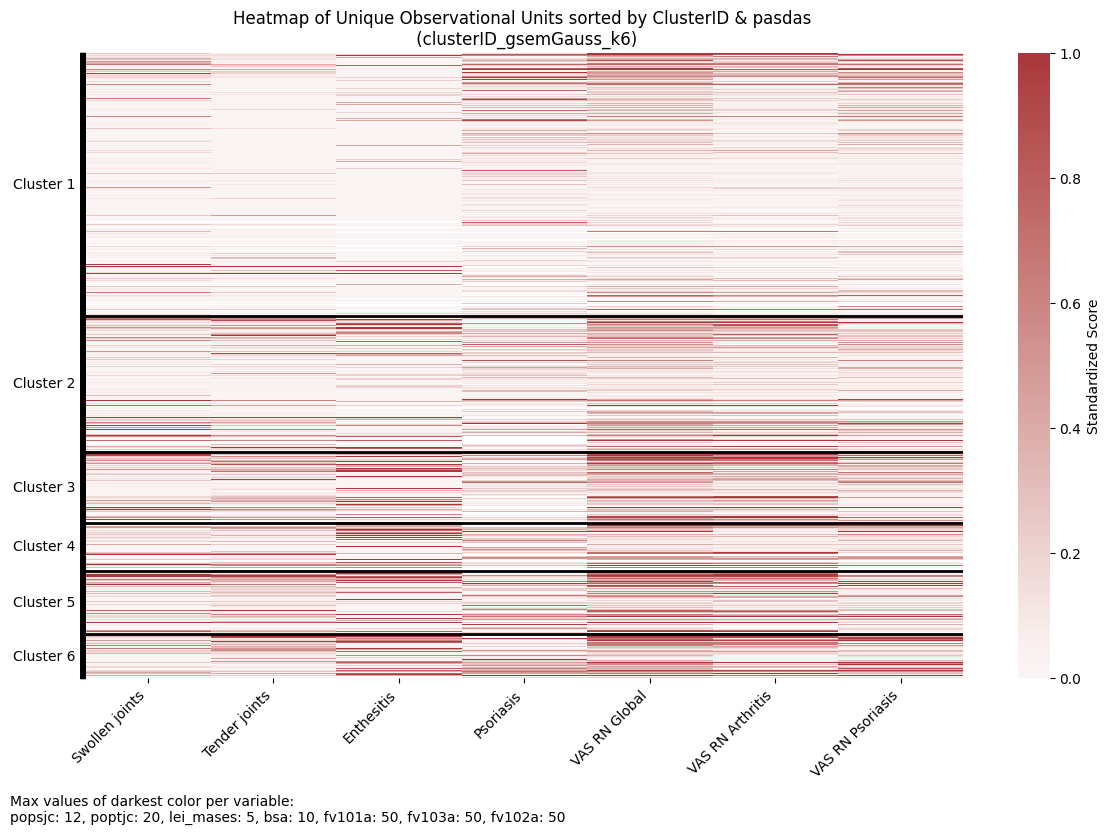

In [59]:
if not debugmode: #skip if debugmode = True
    plot_heatmapCV(data_complete[['pasdas', describe_clusters] + clinical_variables ], 'pasdas', describe_clusters, clinical_variables, clinical_vars_dict, clinical_vars_ylimHM, storefigures, figure_storage)

#### Known Group Validity

In [60]:
def style_crosstab(crosstab_p):
    def grey_nan(val):
        return 'background-color: lightgrey' if pd.isna(val) else ''
    
    return (
        crosstab_p
        .style
        .background_gradient(cmap='OrRd', axis=None)
        .applymap(grey_nan)
        .format(precision=0)
    )

# def cross_tabulate(data, grouping, clusters, states_dict):
#     crosstab = pd.crosstab(data[grouping], data_complete[clusters], dropna=False) # crosstabulation
#     crosstab_p = round(crosstab.div(crosstab.sum(axis=1), axis=0) * 100,1) # To precentages

#     # Map the values to labels for each variable in states_dict
#     if grouping in states_dict:
#         crosstab = crosstab.rename(index=states_dict[grouping])
#         crosstab_p = crosstab_p.rename(index=states_dict[grouping])  # Apply labels to rows (grouping variable)

#     crosstab_p =  style_crosstab(crosstab_p) 
    
#     return crosstab_p

def cross_tabulate(data, grouping, clusters, states_dict):
    # Raw crosstab counts
    crosstab = pd.crosstab(data[grouping], data_complete[clusters]) #drops NaN values

    # ---- 2. Compute row percentages ----
    crosstab_p = round(crosstab.div(crosstab.sum(axis=1), axis=0) * 100, 1)

    # ---- 3. Add (n) to each label ----
    # number of observations per grouping level
    ns = crosstab.sum(axis=1)

    # build new index labels
    new_index = []
    for idx in crosstab.index:
        label = idx
        
        # if mapping exists → use mapped label
        if grouping in states_dict:
            label = states_dict[grouping].get(idx, idx)
        
        # append (n = X)
        label = f"{label} (n = {ns[idx]})"
        new_index.append(label)

    # apply updated row labels
    crosstab_p.index = new_index

    # ---- 4. Apply styling ----
    crosstab_p = style_crosstab(crosstab_p)

    return crosstab_p
    

In [61]:
print(describe_clusters)
print(f'Pasdas missing: {data_complete['pasdas_state'].isna().sum()}')
print(f'DAPSA missing: {data_complete['dapsa_state'].isna().sum()}')

clusterID_gsemGauss_k6
Pasdas missing: 2009
DAPSA missing: 1377


In [62]:
cross_tabulate(data_complete, 'pasdas_state', describe_clusters, states_dict)

clusterID_gsemGauss_k6,1,2,3,4,5,6
Remission (n = 680),90,8,1,1,1,0
Low (n = 1034),49,32,7,7,3,2
Moderate (n = 1222),14,23,20,11,19,12
High (n = 154),3,7,16,4,36,34


In [63]:
cross_tabulate(data_complete, 'dapsa_state', describe_clusters, states_dict)

clusterID_gsemGauss_k6,1,2,3,4,5,6
Remission (n = 940),84,12,1,2,1,0
Low (n = 1586),36,34,12,10,6,2
Moderate (n = 960),9,18,21,11,24,17
High (n = 236),6,14,17,8,28,26


In [64]:
cross_tabulate(data_complete, 'mda_state', describe_clusters, states_dict)

clusterID_gsemGauss_k6,1,2,3,4,5,6
VLDA (n = 731),92,6,1,0,0,0
MDA (n = 1191),59,28,5,5,2,1
No MDA (n = 2461),15,24,19,11,18,13


In [65]:
cross_tabulate(data_complete, 'psaid_state', describe_clusters, states_dict)

clusterID_gsemGauss_k6,1,2,3,4,5,6
Remission (n = 1789),100,0,0,0,0,0
Low (n = 634),53,47,0,0,0,0
Moderate (n = 1037),2,76,14,9,0,0
High (n = 1639),0,2,27,18,32,22


In [66]:
cross_tabulate(data_complete, 'pasdas_state', 'dapsa_state', states_dict)

dapsa_state,0,1,2,3
Remission (n = 619),86,14,0,0
Low (n = 1017),23,72,5,0
Moderate (n = 1215),0,37,54,8
High (n = 154),0,0,32,68


In [67]:
cross_tabulate(data_complete, 'psaid_state', 'dapsa_state', states_dict)

dapsa_state,0,1,2,3
Remission (n = 1204),60,35,4,1
Low (n = 480),24,59,14,3
Moderate (n = 784),10,62,24,4
High (n = 1254),2,31,52,15


In [68]:
cross_tabulate(data_complete, 'psaid_state', 'pasdas_state', states_dict)

pasdas_state,0,1,2,3
Remission (n = 1076),54,36,10,0
Low (n = 390),13,60,27,0
Moderate (n = 615),6,41,50,2
High (n = 1009),1,16,70,14


In [69]:
cross_tabulate(data_complete, 'mda_state', 'pasdas_state', states_dict)

pasdas_state,0,1,2,3
VLDA (n = 486),81,18,0,0
MDA (n = 829),25,65,10,0
No MDA (n = 1657),0,22,68,9


In [70]:
cross_tabulate(data_complete, 'mda_state', 'dapsa_state', states_dict)

dapsa_state,0,1,2,3
VLDA (n = 571),97,3,0,0
MDA (n = 996),32,66,2,0
No MDA (n = 2029),0,42,46,12


In [71]:
cross_tabulate(data_complete, 'mda_state', 'psaid_state', states_dict)

psaid_state,0,1,2,3
VLDA (n = 731),87,8,4,1
MDA (n = 1191),48,20,23,10
No MDA (n = 2461),9,10,25,55


#### Box plot by Clinical Variables

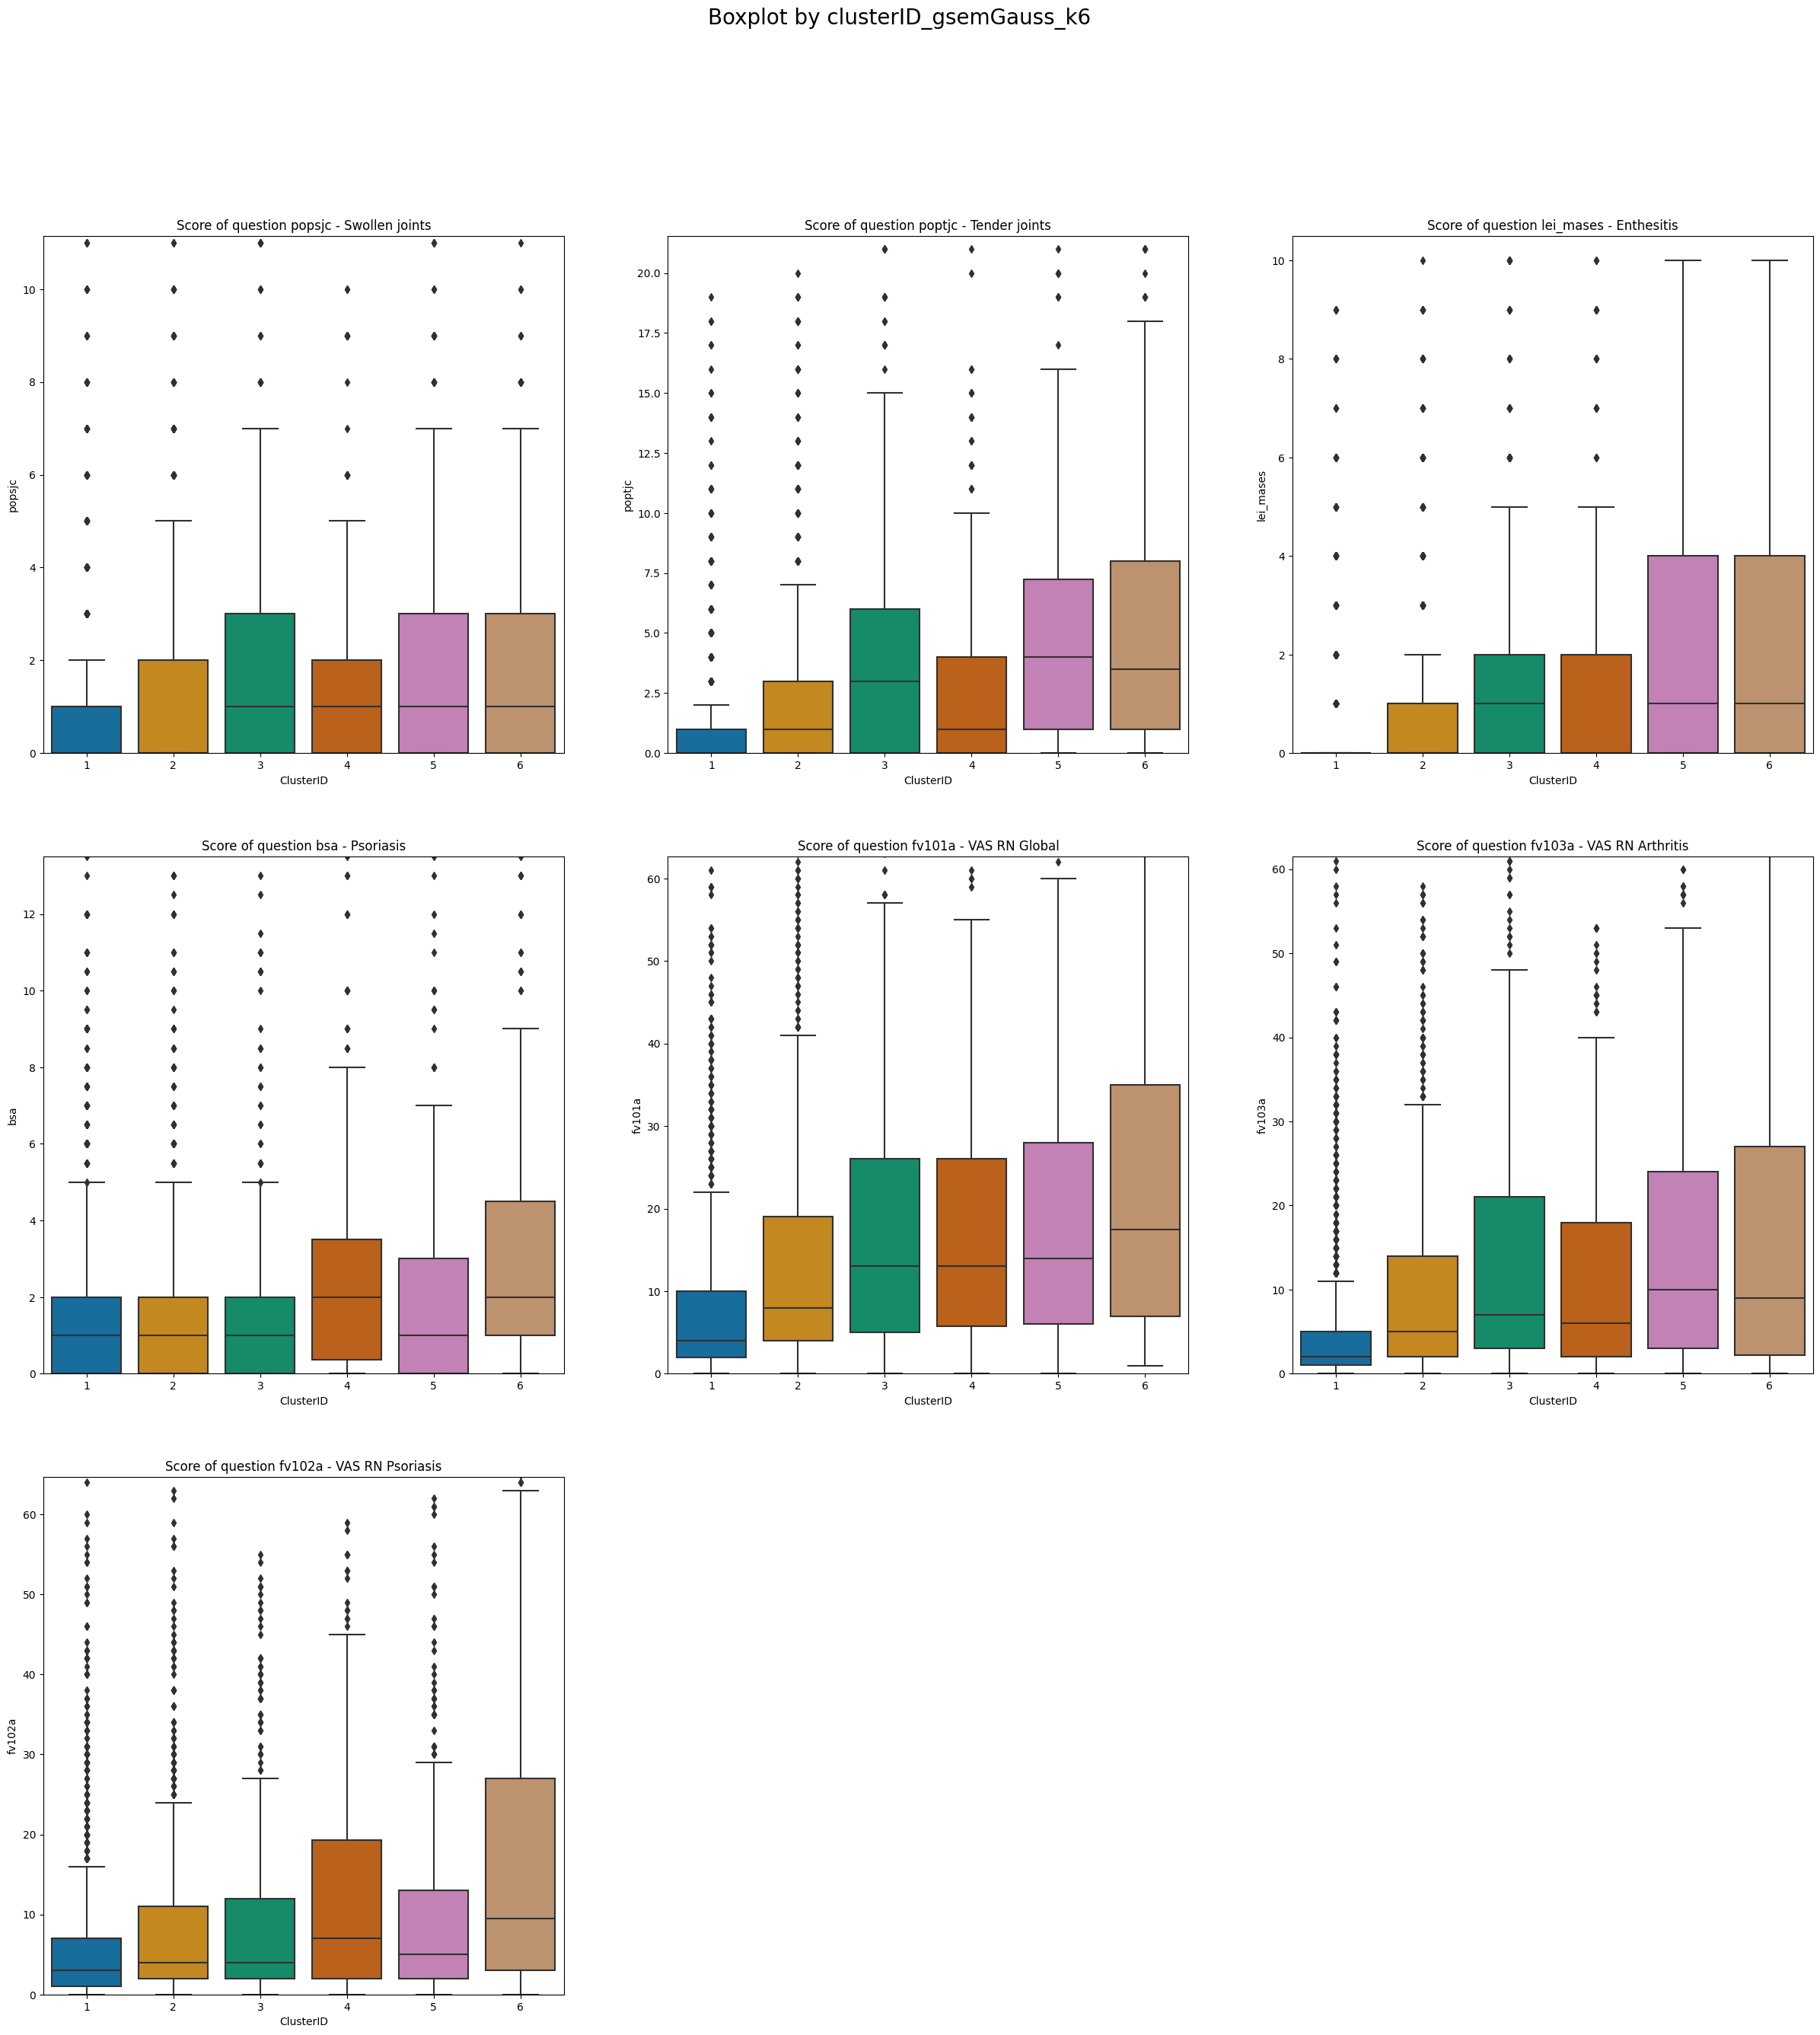

In [72]:
plot_boxplot_byvars(data_complete, clinical_variables, describe_clusters, clinical_vars_dict, custom_palette, storefigures, clinical_vars_ylimBP)

#### Spider Chart / Radial Chart

In [73]:
# Variables and example data
def plot_radar_chartCV(cluster_assignment, varlist, cluster_medians, cluster_size, domains_dict, clinical_vars_ylim, custom_palette, storefigures):

    # Set up the radar chart axes
    angles = np.linspace(0, 2 * np.pi, len(varlist), endpoint=False).tolist()
    angles += angles[:1]  # Close the circle
    # print(f' ANgles: {len(angles)}')

    # Define Figure Grid
    num_clusters = cluster_stats_cv.shape[0]
    cols = min(3, num_clusters)
    rows = math.ceil(num_clusters / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6), subplot_kw=dict(polar=True))
    axes = np.atleast_2d(axes)

    # Repeat the first value to close the circular plot
    cluster_medians += cluster_medians[:1]
    # print(f'Medians: {cluster_medians.shape}')

    # Plot the means for each cluster 
    for cluster in range(len(cluster_medians)):
        row = cluster// cols
        col = cluster % cols
        ax = axes[row, col]
        
        values = cluster_stats_cv.xs('median', axis=1, level=1)[varlist].iloc[cluster].tolist()
        scaled_values = [v / clinical_vars_ylim[var] for v, var in zip(values, varlist)]
        scaled_values += scaled_values[:1] # Close the loop by repeating the first value

        # Plot values
        ax.plot(angles, scaled_values, label=f'Cluster {cluster} (n={cluster_size[cluster]})', linewidth=2, linestyle='solid', color=custom_palette[cluster])
        ax.fill(angles, scaled_values, alpha=0.25, color = custom_palette[cluster])

        # Customize the chart
        ax.set_title(f'Cluster {cluster} (n={cluster_size[cluster]})', size=15, va='bottom')
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
        ax.set_yticklabels([])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([domains_dict[label] for label in varlist], size=10) #Replace labels as specified in the dictionary with PsAID Domains
        # Make sure the labels do not overlap with the figure by aligning them properly
        for label, angle in zip(ax.get_xticklabels(), angles):
            angle_deg = np.degrees(angle)
            if angle_deg < 90 or angle_deg > 270:        # If text on the leftside of the circle
                label.set_horizontalalignment('left')    # Align text left
            elif angle_deg == 90 or angle_deg == 270:    # If text top or bottom of the circle
                label.set_horizontalalignment('center') # Align text Middle
            else:                                        # Else, if text on rightside of the circle
                label.set_horizontalalignment('right')   # Align text right

    # Hide unused subplots
    for cluster in range(num_clusters, rows * cols):
        fig.delaxes(axes.flatten()[cluster])

    # Add explanatory text
    ylim_text = "Max values per axis:\n" + ", ".join(
        [f"{domains_dict.get(var, var)}: {clinical_vars_ylim[var]}" for var in varlist]
    )

    # Add the textbox at the bottom center
    fig.text(0.01, 0.01, ylim_text, ha='left', va='bottom', fontsize=10, wrap=True)

    # Display the plot
    plt.tight_layout()
    fig.suptitle(f'Radar Chart of Clinical Variable Medians by {cluster_assignment}', size=16, va='bottom')
    if storefigures == True:
        plt.savefig(os.path.join(figure_storage, f'PsAID_{cluster_assignment}_Radar by Clinical Variable Medians .png'))
    plt.show()

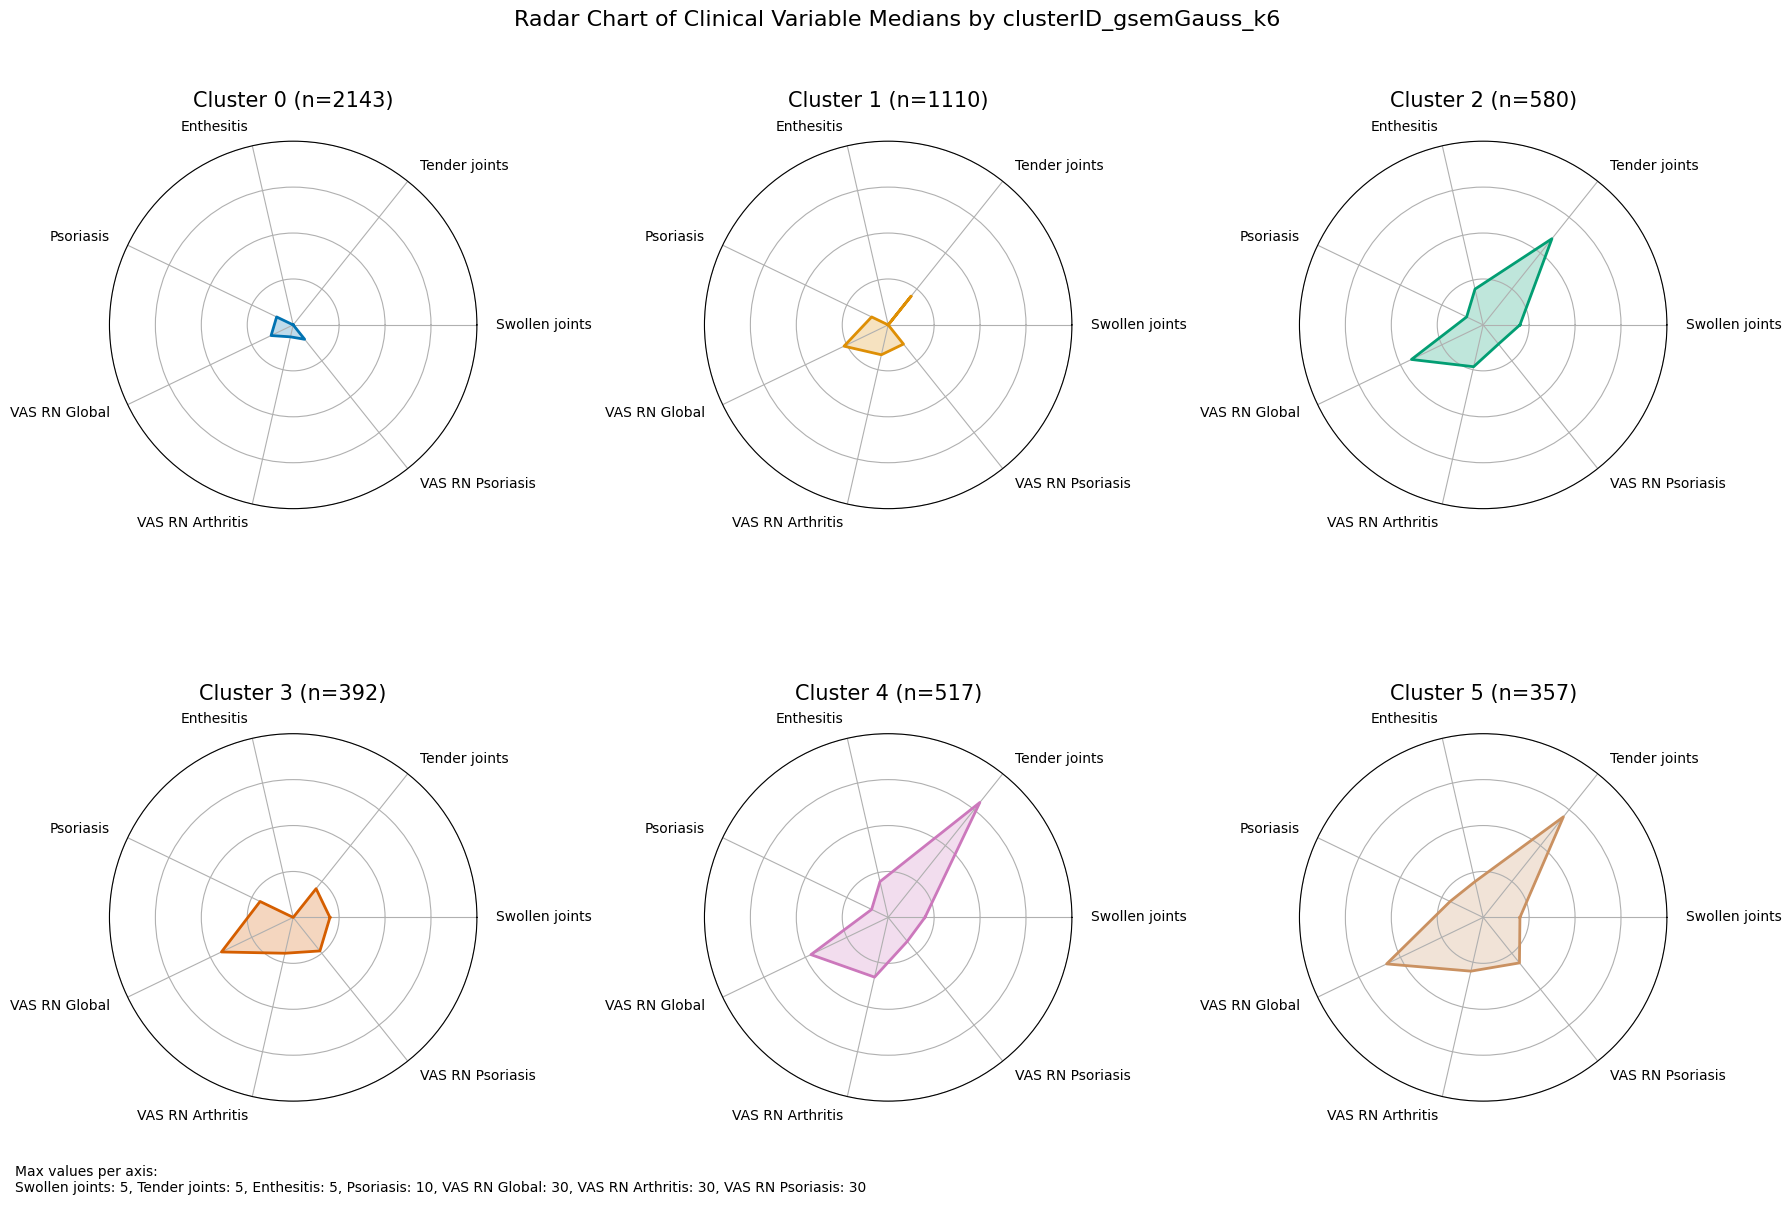

In [74]:
plot_radar_chartCV(describe_clusters, clinical_variables, cluster_stats_cv.xs('median', axis=1, level=1)[clinical_variables], cluster_size, clinical_vars_dict,  clinical_vars_ylimRC, custom_palette, storefigures)

In [77]:
data_complete[['respondentid', 'mm', describe_clusters]].to_csv(f'{folder_path}/{'cluster_assignment'}.csv', index=False)

In [78]:
folder_path

'/Users/pattydegroot/Documents/Python/PsAID-Cluster-Analysis/Selected Clustering Solutions/PsAID_clusterID_gsemGauss_k6'